# EDA — La Réunion PV Fault Detection Dataset

**Objective:** Thorough data understanding before any feature engineering or modeling.

**Pipeline position:** This notebook runs AFTER ingestion (merged parquet exists) and BEFORE feature engineering, splitting, or any model training.

**What we check here:**
1. Basic stats & schema validation
2. Temporal coverage & sampling regularity
3. Missing value analysis (MCAR/MAR/MNAR patterns)
4. Target (Fault) distribution & temporal structure
5. Univariate distributions — normal vs fault
6. Day/night segmentation (irradiance = 0 → no production)
7. Correlation & collinearity (VIF) — raw features
8. Mutual information with target
9. Outlier analysis
10. Stationarity diagnostics
11. Sensor health checks (stuck-at, drift)
12. Differential signal preview (dt2 vs dt3)
13. Key findings & recommendations

## Before We Start: Understanding Our Tools

This notebook uses several Python libraries. Here's a quick guide:

| Library | What it does | Analogy |
|---------|-------------|---------|
| **NumPy** (`np`) | Fast math on arrays of numbers | A scientific calculator that works on entire columns at once |
| **Pandas** (`pd`) | Tabular data (rows & columns), like Excel in Python | A programmable spreadsheet |
| **Polars** (`pl`) | Same idea as Pandas, but much faster for large data | A turbo-charged spreadsheet |
| **Matplotlib** (`plt`) | Creates charts and plots | A drawing canvas for graphs |
| **Seaborn** (`sns`) | Prettier statistical charts, built on top of Matplotlib | A theme pack for your graphs |
| **SciPy** (`stats`) | Statistical tests (hypothesis testing, distributions) | A statistics textbook that computes for you |
| **scikit-learn** | Machine learning algorithms and utilities | The ML Swiss Army knife |

### Key Pandas Concepts You'll See
- **DataFrame**: A table (rows x columns). Like a CSV loaded into memory.
- **Series**: A single column from a DataFrame.
- `.shape` → returns `(n_rows, n_columns)` — the size of your table
- `.describe()` → gives count, mean, std, min, quartiles, max for each column
- `.value_counts()` → counts how many times each unique value appears
- `.groupby("col")` → splits data into groups by a column, then you aggregate (sum, mean, etc.)
- `.isnull()` → returns True/False for each cell: is it missing?
- `.dropna()` → removes rows with any missing values
- `.corr()` → computes correlation between all pairs of columns

### Key Statistics Concepts You'll See
- **Mean**: Average value. Sum all values, divide by count. Sensitive to outliers.
- **Median**: Middle value when sorted. Robust to outliers.
- **Standard Deviation (std)**: How spread out the data is. Small std = values are close together.
- **Quartiles (Q1, Q3)**: Q1 = 25th percentile, Q3 = 75th percentile. Middle 50% of data is between Q1 and Q3.
- **IQR (Interquartile Range)**: Q3 - Q1. Used to detect outliers. outlier if x < Q1 − 1.5×IQR
- **p-value**: The probability of seeing your result *if the null hypothesis were true*. p < 0.05 = statistically significant.
A p-value is NOT:
❌ probability that the null hypothesis is true
It is:
✔ probability of the data given the null hypothesis
- **Spearman Correlation (ρ)**: Measures monotonic relationship between two variables (works for non-linear relationships too). ρ = +1 (perfect monotonic increase), ρ = -1 (perfect decrease), ρ = 0 (no monotonic relationship). Better than Pearson for PV data which has non-linear sensor dynamics.
- **Normal distribution**: Bell-shaped curve. Most natural phenomena follow this approximately.

In [80]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from loguru import logger

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 100,
    "font.size": 10,
})
sns.set_theme(style="whitegrid", palette="muted")

PROJECT_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd().parent
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "University of La Réunion Data"

print(f"Project root: {PROJECT_ROOT}")
print(f"Interim dir:  {INTERIM_DIR}")

Project root: c:\Users\AmineTECH\Documents\DevProjects\pfe-experiments\PFE_Experiments
Interim dir:  c:\Users\AmineTECH\Documents\DevProjects\pfe-experiments\PFE_Experiments\data\interim


### What the imports cell above does, line by line

```python
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
```
Python sometimes shows "FutureWarning" messages — things that will change in future library versions. We silence them so our output stays clean. This is cosmetic, NOT hiding real errors.

```python
import numpy as np          # Math on arrays. "np" is the conventional alias.
import pandas as pd         # DataFrames (tables). "pd" is the convention.
import polars as pl         # Faster DataFrames. We use it for loading, then convert to pandas.
import matplotlib.pyplot as plt  # Plotting. "plt" is the convention.
import seaborn as sns       # Statistical plots on top of matplotlib.
from pathlib import Path    # Modern way to handle file paths (works on Windows, Mac, Linux)
from scipy import stats     # Statistical tests (Mann-Whitney, etc.)
from loguru import logger   # Better logging (colored, timestamped messages)
```

```python
plt.rcParams.update({...})  # Global plot settings:
    # "figure.figsize": (14, 6)   → default plot size: 14 inches wide, 6 tall
    # "axes.titlesize": 13        → font size for plot titles
    # "figure.dpi": 100           → resolution (dots per inch)
```

```python
sns.set_theme(style="whitegrid", palette="muted")
```
Sets a visual theme for all plots. "whitegrid" = white background with grid lines. "muted" = soft colors.

```python
PROJECT_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd().parent
```
This figures out where our project folder is. In a notebook, `__file__` doesn't exist, so it falls back to `Path.cwd().parent` — the parent of the current working directory.

```python
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
```
The `/` operator on `Path` objects joins path segments. This builds the path `project/data/interim/` where we store intermediate results.

## 1. Load Merged Data & Basic Stats

In [81]:
# Load the merged parquet (dt2 electrical + dt1 meteorological)
parquet_path = INTERIM_DIR / "reunion_dt2_merged.parquet"
df = pl.read_parquet(parquet_path)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns}")
print(f"Schema:\n{df.schema}")
print(f"\nMemory estimate: {df.estimated_size('mb'):.1f} MB")
df.head(5)

Shape: (2988814, 13)
Columns: ['time', 'Fault', 'Ia', 'Ig', 'Eg', 'Fg', 'Pg', 'Va', 'Vg', 'DTI', 'GTI', 'TA', 'TPV']
Schema:
Schema([('time', Datetime(time_unit='us', time_zone='UTC')), ('Fault', Float64), ('Ia', Float64), ('Ig', Float64), ('Eg', Float64), ('Fg', Float64), ('Pg', Float64), ('Va', Float64), ('Vg', Float64), ('DTI', Float64), ('GTI', Float64), ('TA', Float64), ('TPV', Float64)])

Memory estimate: 297.4 MB


time,Fault,Ia,Ig,Eg,Fg,Pg,Va,Vg,DTI,GTI,TA,TPV
"datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2021-10-01 10:10:02 UTC,0.0,3.1,2.3,6.893,49.94,546.0,189.0,236.0,null,null,null,null
2021-10-01 10:10:09 UTC,0.0,3.1,2.2,6.893,49.91,534.0,189.0,236.0,null,null,null,null
2021-10-01 10:10:16 UTC,0.0,3.0,2.2,6.893,49.92,523.0,189.0,235.0,null,null,null,null
2021-10-01 10:10:23 UTC,0.0,2.9,2.1,6.893,49.88,507.0,188.0,235.0,null,null,null,null
2021-10-01 10:10:30 UTC,0.0,2.8,2.1,6.893,49.97,498.0,188.0,236.0,null,null,null,null


### Understanding the data loading above

**What is Parquet?** A file format for storing tabular data. Unlike CSV (plain text), Parquet is *binary* and *columnar*:
- **Binary**: Not human-readable, but much smaller and faster to load
- **Columnar**: Data is stored column-by-column (not row-by-row). This means reading just one column is instant — you don't need to scan all rows. Perfect for big data.

**Why Polars for loading?** Polars (`pl.read_parquet(...)`) is written in Rust and can load data 5-10x faster than Pandas. For ~3 million rows, this matters.

```python
df = pl.read_parquet(parquet_path)   # Load entire file into memory as a Polars DataFrame
df.shape                             # → (n_rows, n_columns) — e.g., (2990000, 13)
df.columns                           # → list of column names: ["time", "Ia", "Ig", ...]
df.schema                            # → maps column_name → data type (Float64, Datetime, etc.)
df.estimated_size('mb')              # → how much RAM this uses, in megabytes
df.head(5)                           # → show first 5 rows (a quick sanity check)
```

**Why do we then convert to Pandas?** Polars is fast for loading and transformations, but Pandas has richer integration with plotting libraries (matplotlib, seaborn) and scikit-learn. So we load fast with Polars, then work with Pandas.

```python
pdf = df.to_pandas()        # Convert Polars DataFrame → Pandas DataFrame
pdf.info(memory_usage="deep")  # Shows: column names, non-null counts, data types, total memory
```

### Understanding column classification

```python
LABEL_COL = "Fault"         # This is our TARGET — what we want to predict
TIME_COL = "time"           # Timestamp column — NOT a feature, used for ordering/splitting
ELECTRICAL_COLS = [...]     # Sensor readings from the inverter (current, voltage, power, etc.)
METEO_COLS = [...]          # Weather station readings (irradiance, temperature)
FEATURE_COLS = ELECTRICAL_COLS + METEO_COLS   # All input features combined
```

**What is `.describe()`?** It computes summary statistics for each column:
- `count`: number of non-null values
- `mean`: arithmetic average = $\frac{1}{n}\sum_{i=1}^{n} x_i$
- `std`: standard deviation = $\sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$ — measures spread
- `min/max`: smallest/largest values
- `25%/50%/75%`: quartiles (50% = median). These split the data into four equal parts.

In [82]:
# Convert to pandas for EDA (polars is fast for loading, pandas has richer plotting)
pdf = df.to_pandas()
pdf.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2988814 entries, 0 to 2988813
Data columns (total 13 columns):
 #   Column  Dtype              
---  ------  -----              
 0   time    datetime64[us, UTC]
 1   Fault   float64            
 2   Ia      float64            
 3   Ig      float64            
 4   Eg      float64            
 5   Fg      float64            
 6   Pg      float64            
 7   Va      float64            
 8   Vg      float64            
 9   DTI     float64            
 10  GTI     float64            
 11  TA      float64            
 12  TPV     float64            
dtypes: datetime64[us, UTC](1), float64(12)
memory usage: 296.4 MB


In [83]:
# Column classification
LABEL_COL = "Fault"
TIME_COL = "time"
ELECTRICAL_COLS = ["Ia", "Ig", "Eg", "Fg", "Pg", "Va", "Vg"]
METEO_COLS = ["GTI", "DTI", "TA", "TPV"]
FEATURE_COLS = ELECTRICAL_COLS + METEO_COLS

print("=== Descriptive Statistics ===")
pdf[FEATURE_COLS + [LABEL_COL]].describe().round(3)

=== Descriptive Statistics ===


,Ia,Ig,Eg,Fg,Pg,Va,Vg,GTI,DTI,TA,TPV,Fault
count,2988804.000,2988804.000,2988804.000,2988804.000,2988804.000,2988804.000,2988804.000,2937822.000,2937822.000,2937822.000,2937822.000,2988808.000
mean,3.841,2.731,3.424,49.910,650.347,180.985,233.412,496.270,168.198,29.025,40.409,0.100
std,2.895,2.020,2.633,1.928,475.693,13.602,9.187,366.338,128.024,4.836,12.149,0.603
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.376,1.342,15.390,13.300,0.000
25%,1.100,0.800,0.861,49.950,201.000,175.000,233.000,156.800,76.510,25.470,30.070,0.000
50%,3.200,2.300,3.226,49.980,545.000,183.000,234.000,424.800,122.100,28.760,39.850,0.000
75%,6.500,4.600,5.633,50.020,1096.000,188.000,235.000,831.000,233.400,32.470,50.580,0.000
max,11.400,9.200,9.493,50.370,2195.000,241.000,248.000,1744.000,753.900,48.090,71.760,4.000


## 2. Temporal Coverage & Sampling Regularity

Critical questions:
- Is the sampling rate truly ~7s throughout?
- Are there gaps? How long? When?
- Does the meteorological join leave nulls? (dt1 starts 27 days after dt2)

In [84]:
# Time range
t_min, t_max = pdf[TIME_COL].min(), pdf[TIME_COL].max()
print(f"Time range: {t_min} → {t_max}")
print(f"Duration:   {(t_max - t_min).days} days")
print(f"Total rows: {len(pdf):,}")

Time range: 2021-10-01 10:10:02+00:00 → 2023-04-13 13:42:27+00:00
Duration:   559 days
Total rows: 2,988,814


In [85]:
# Sampling interval analysis
dt_seconds = pdf[TIME_COL].diff().dt.total_seconds().dropna()
print(f"\n=== Sampling Interval (seconds) ===")
print(f"Mean:   {dt_seconds.mean():.2f}")
print(f"Median: {dt_seconds.median():.2f}")
print(f"Std:    {dt_seconds.std():.2f}")
print(f"Min:    {dt_seconds.min():.2f}")
print(f"Max:    {dt_seconds.max():.2f}")
print(f"Mode:   {dt_seconds.mode().values[0]:.2f}")

# Intervals > 1 minute = significant gaps
gap_mask = dt_seconds > 60
n_gaps = gap_mask.sum()
print(f"\nGaps > 1 minute: {n_gaps}")
if n_gaps > 0:
    gap_locs = dt_seconds[gap_mask]
    print(f"  Max gap: {gap_locs.max():.0f}s ({gap_locs.max()/3600:.1f}h)")
    print(f"  Mean gap: {gap_locs.mean():.0f}s")


=== Sampling Interval (seconds) ===
Mean:   16.16
Median: 6.00
Std:    2584.06
Min:    4.00
Max:    2848806.00
Mode:   6.00

Gaps > 1 minute: 513
  Max gap: 2848806s (791.3h)
  Mean gap: 59714s


### Understanding sampling interval analysis

**What is `.diff()`?** It computes the difference between each row and the previous row:
```
Row 0: 10:00:00    → NaN (no previous row)
Row 1: 10:00:07    → 7 seconds
Row 2: 10:00:14    → 7 seconds
Row 3: 10:00:28    → 14 seconds  ← gap!
```

**`.dt.total_seconds()`** converts a time difference (timedelta) to a plain number in seconds.

**Why check sampling intervals?** Our data claims to sample every ~7 seconds. But real sensors have:
- **Dropouts**: sensor goes offline → gaps
- **Irregular sampling**: sensor clock drifts

This matters because:
1. **Feature engineering** (later) computes rates of change (dP/dt). Irregular dt breaks this.
2. **Windowing**: we'll create fixed-size windows. Gaps mean some windows span hours, not minutes.
3. **Train/test split**: gaps might naturally separate our data into chunks.

**Statistics used here:**
- **Mean**: average interval. If 7.0, most readings are ~7s apart.
- **Median**: middle value. If mean ≠ median, there are outliers (extreme gaps pulling the mean up).
- **Mode**: most common value. Should be exactly 7 if the sensor is regular.
- **Std (standard deviation)**: if std is small (e.g., 0.5), intervals are consistent. If large (e.g., 100), many irregular gaps.

**Gap detection:** We flag any interval > 60 seconds as a "significant gap." This is a design choice — 60s is 8-9 missed readings.

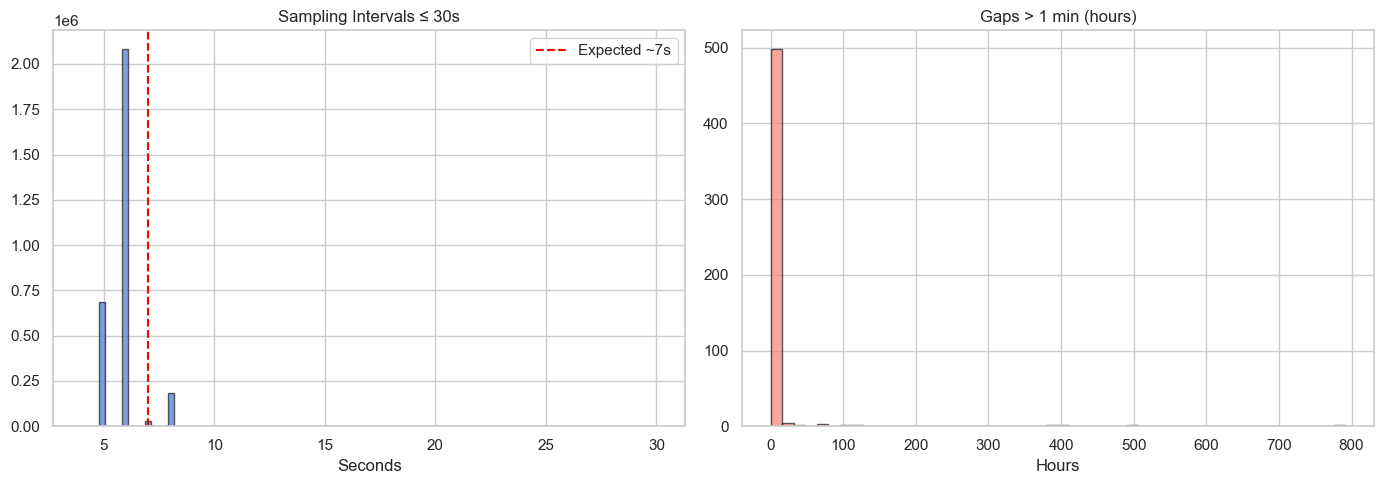

In [86]:
# Distribution of sampling intervals (zoom into normal range)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dt_seconds[dt_seconds <= 30], bins=100, edgecolor="k", alpha=0.7)
axes[0].set_title("Sampling Intervals ≤ 30s")
axes[0].set_xlabel("Seconds")
axes[0].axvline(7, color="red", ls="--", label="Expected ~7s")
axes[0].legend()

# Large gaps distribution
axes[1].hist(dt_seconds[dt_seconds > 60] / 3600, bins=50, edgecolor="k", alpha=0.7, color="salmon")
axes[1].set_title("Gaps > 1 min (hours)")
axes[1].set_xlabel("Hours")
plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_sampling_intervals.png", bbox_inches="tight")
plt.show()

### Understanding histograms

**What is a histogram?** It divides the range of values into "bins" (buckets) and counts how many values fall into each bin. It shows the **distribution** — where values concentrate.

```python
axes[0].hist(dt_seconds[dt_seconds <= 30], bins=100, edgecolor="k", alpha=0.7)
```
- `dt_seconds[dt_seconds <= 30]` — **boolean indexing**: only keep values ≤ 30. The expression `dt_seconds <= 30` creates a True/False mask, and Pandas uses it to filter.
- `bins=100` — divide the range (min max value) into 100 buckets
- `edgecolor="k"` — black outlines on bars ("k" = black in matplotlib)
- `alpha=0.7` — 70% opacity (slight transparency)

```python
axes[0].axvline(7, color="red", ls="--", label="Expected ~7s")
```
Draws a vertical line at x=7. If the histogram peak aligns with this line, our sampling rate is correct.

```python
plt.savefig(INTERIM_DIR / "eda_sampling_intervals.png", bbox_inches="tight")
```
Saves the plot as a PNG image file. `bbox_inches="tight"` crops whitespace around the figure.

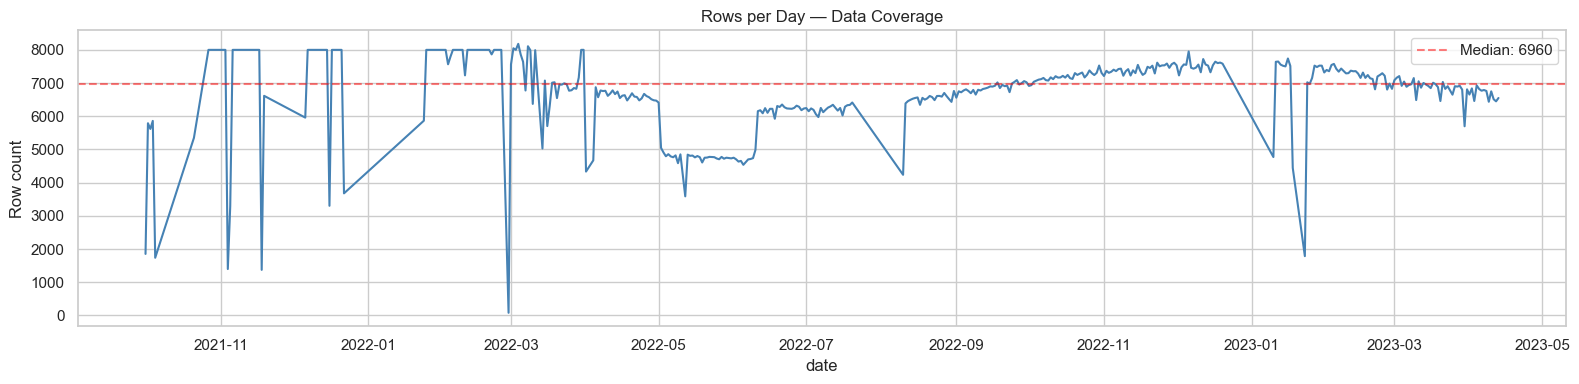

In [87]:
# Daily data coverage (rows per day)
pdf["date"] = pdf[TIME_COL].dt.date
daily_counts = pdf.groupby("date").size()
fig, ax = plt.subplots(figsize=(16, 4))
daily_counts.plot(ax=ax, color="steelblue")
ax.set_title("Rows per Day — Data Coverage")
ax.set_ylabel("Row count")
ax.axhline(daily_counts.median(), color="red", ls="--", alpha=0.5, label=f"Median: {daily_counts.median():.0f}")
ax.legend()
plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_daily_coverage.png", bbox_inches="tight")
plt.show()

### 2.1 Gap Characterization & Handling Strategy

The sampling analysis above reveals **513 gaps > 1 minute**, with the worst being **~791 hours (~33 days)**. This is a critical problem for any windowed time-series model because:

1. **Windows spanning gaps are invalid:** A 60-sample window that straddles a 2-hour gap mixes readings from completely different conditions
2. **Interpolation across large gaps is meaningless:** You can't interpolate solar power over a 33-day gap — weather, season, and panel state all changed
3. **Rate-of-change features break:** `dP/dt` computed across a gap produces nonsensical values

**Strategy:** Segment the data into **contiguous chunks** separated at gaps above a threshold, and **never build windows across chunk boundaries**.

=== Gap Classification ===
   1-5 min:   49 gaps  (median:      2.4 min, max:      0.1 h)
   5min-1h:   22 gaps  (median:      8.9 min, max:      0.4 h)
     1-24h:  429 gaps  (median:    760.5 min, max:     20.9 h)
      >24h:   13 gaps  (median:   6594.7 min, max:    791.3 h)

  Total data gaps > 1min: 513
  Total time lost to gaps: 8509.2 hours (354.6 days)


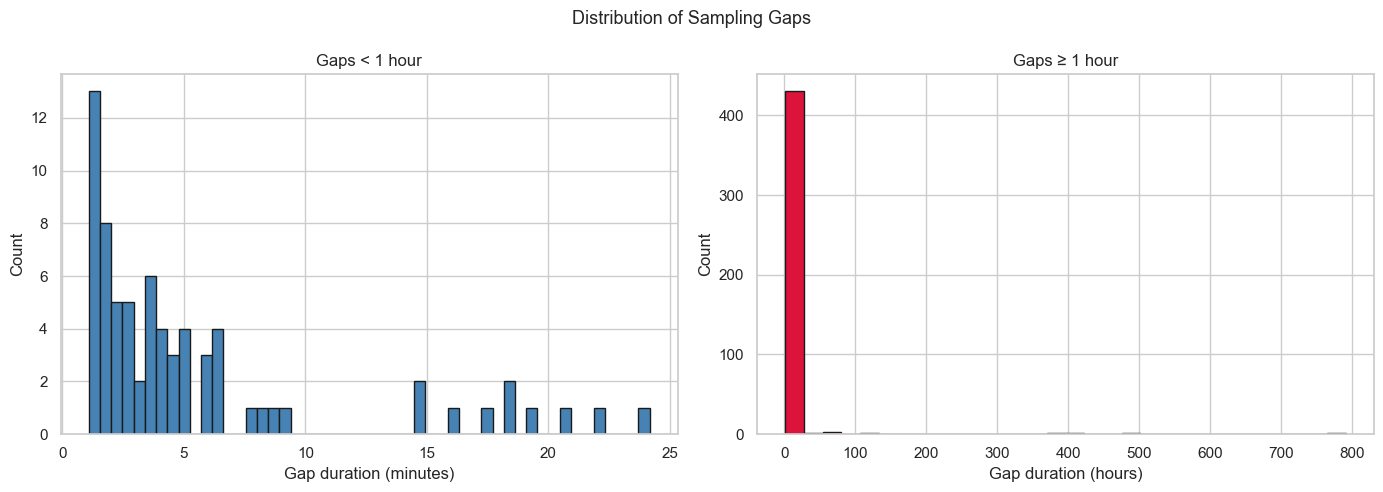

In [88]:
# === Gap Classification ===
# Categorize gaps by severity
gap_durations = dt_seconds[dt_seconds > 60].copy()  # gaps > 1 minute

bins = [60, 300, 3600, 86400, float("inf")]  # 1min, 5min, 1h, 24h
labels = ["1-5 min", "5min-1h", "1-24h", ">24h"]
gap_categories = pd.cut(gap_durations, bins=bins, labels=labels)

print("=== Gap Classification ===")
gap_counts = gap_categories.value_counts().sort_index()
for cat, count in gap_counts.items():
    subset = gap_durations[gap_categories == cat]
    print(f"  {cat:>8s}: {count:4d} gaps  (median: {subset.median()/60:8.1f} min, max: {subset.max()/3600:8.1f} h)")

print(f"\n  Total data gaps > 1min: {len(gap_durations)}")
print(f"  Total time lost to gaps: {gap_durations.sum()/3600:.1f} hours ({gap_durations.sum()/86400:.1f} days)")

# Gap duration histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(gap_durations[gap_durations < 3600] / 60, bins=50, color="steelblue", edgecolor="k")
axes[0].set_title("Gaps < 1 hour")
axes[0].set_xlabel("Gap duration (minutes)")
axes[0].set_ylabel("Count")

axes[1].hist(gap_durations[gap_durations >= 3600] / 3600, bins=30, color="crimson", edgecolor="k")
axes[1].set_title("Gaps ≥ 1 hour")
axes[1].set_xlabel("Gap duration (hours)")
axes[1].set_ylabel("Count")

plt.suptitle("Distribution of Sampling Gaps", fontsize=13)
plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_gap_distribution.png", bbox_inches="tight")
plt.show()

In [89]:
# === Segment the data into contiguous chunks ===
# A "chunk" = a run of data with no gap > GAP_THRESHOLD between consecutive readings
GAP_THRESHOLD_S = 300  # 5 minutes = ~42 missed readings at 7s sampling

gap_flags = dt_seconds > GAP_THRESHOLD_S
# Prepend False for the first row (no gap before it)
gap_flags_full = pd.Series([False] + gap_flags.tolist(), index=pdf.index)
segment_ids = gap_flags_full.cumsum()
pdf["segment_id"] = segment_ids.values

# Analyze segments
seg_stats = pdf.groupby("segment_id").agg(
    n_rows=(TIME_COL, "count"),
    start=(TIME_COL, "first"),
    end=(TIME_COL, "last"),
    n_faults=(LABEL_COL, lambda x: (x != 0.0).sum()),
).reset_index()
seg_stats["duration_h"] = (seg_stats["end"] - seg_stats["start"]).dt.total_seconds() / 3600
seg_stats["pct_fault"] = (seg_stats["n_faults"] / seg_stats["n_rows"] * 100).round(1)

print(f"=== Contiguous Segments (gap threshold: {GAP_THRESHOLD_S}s = {GAP_THRESHOLD_S/60:.0f} min) ===")
print(f"  Total segments: {len(seg_stats)}")
print(f"  Segment sizes (rows): min={seg_stats['n_rows'].min()}, median={seg_stats['n_rows'].median():.0f}, max={seg_stats['n_rows'].max():,}")
print(f"  Segment durations (h): min={seg_stats['duration_h'].min():.1f}, median={seg_stats['duration_h'].median():.1f}, max={seg_stats['duration_h'].max():.1f}")

# Size distribution
print(f"\n  Segments by size:")
size_bins = [0, 100, 1000, 10000, 100000, float("inf")]
size_labels = ["<100", "100-1K", "1K-10K", "10K-100K", ">100K"]
seg_size_cats = pd.cut(seg_stats["n_rows"], bins=size_bins, labels=size_labels)
for cat in size_labels:
    count = (seg_size_cats == cat).sum()
    rows_in_cat = seg_stats.loc[seg_size_cats == cat, "n_rows"].sum()
    print(f"    {cat:>8s}: {count:3d} segments, {rows_in_cat:>10,} rows ({rows_in_cat/len(pdf)*100:.1f}%)")

# Minimum usable segment: need at least WINDOW_SIZE rows to form 1 window
MIN_WINDOW_SIZE = 60  # typical window size
usable = seg_stats[seg_stats["n_rows"] >= MIN_WINDOW_SIZE]
usable_rows = usable["n_rows"].sum()
print(f"\n  Usable segments (≥{MIN_WINDOW_SIZE} rows): {len(usable)} / {len(seg_stats)}")
print(f"  Usable rows: {usable_rows:,} / {len(pdf):,} ({usable_rows/len(pdf)*100:.1f}%)")
print(f"  Rows lost to tiny segments: {len(pdf) - usable_rows:,} ({(len(pdf)-usable_rows)/len(pdf)*100:.1f}%)")

=== Contiguous Segments (gap threshold: 300s = 5 min) ===
  Total segments: 465
  Segment sizes (rows): min=3, median=6904, max=8,181
  Segment durations (h): min=0.0, median=11.1, max=13.3

  Segments by size:
        <100:  13 segments,        568 rows (0.0%)
      100-1K:   5 segments,      1,516 rows (0.1%)
      1K-10K: 447 segments,  2,986,730 rows (99.9%)
    10K-100K:   0 segments,          0 rows (0.0%)
       >100K:   0 segments,          0 rows (0.0%)

  Usable segments (≥60 rows): 455 / 465
  Usable rows: 2,988,507 / 2,988,814 (100.0%)
  Rows lost to tiny segments: 307 (0.0%)


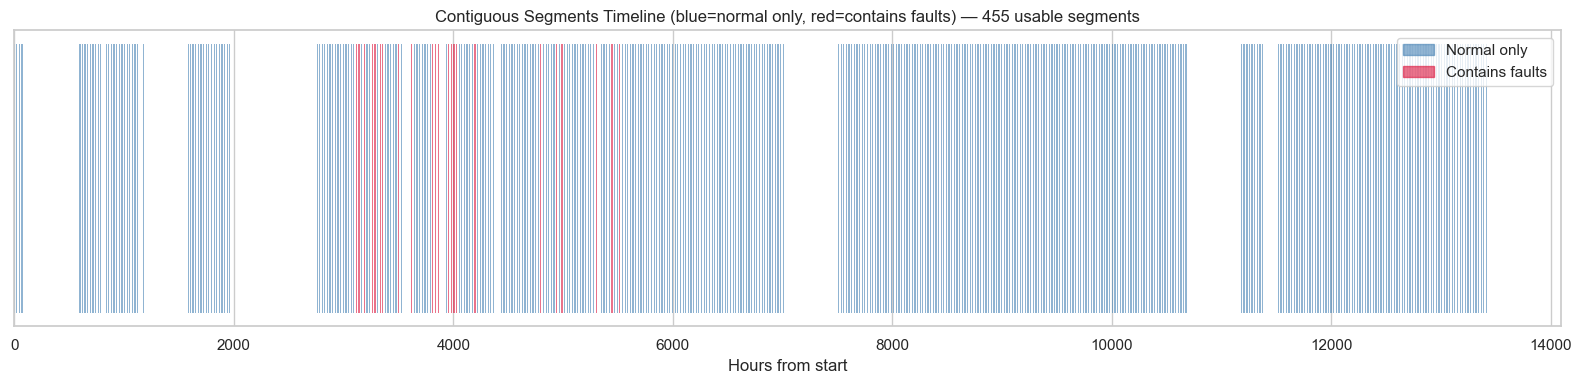

In [90]:
# Visualize: timeline of segments with gaps highlighted
fig, ax = plt.subplots(figsize=(16, 4))

for _, seg in usable.iterrows():
    color = "crimson" if seg["pct_fault"] > 0 else "steelblue"
    ax.barh(0, seg["duration_h"], left=(seg["start"] - pdf[TIME_COL].min()).total_seconds() / 3600,
            height=0.6, color=color, alpha=0.6, edgecolor="none")

ax.set_xlabel("Hours from start")
ax.set_title(f"Contiguous Segments Timeline (blue=normal only, red=contains faults) — {len(usable)} usable segments")
ax.set_yticks([])

# Add legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", alpha=0.6, label="Normal only"),
                    Patch(color="crimson", alpha=0.6, label="Contains faults")],
          loc="upper right")
plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_segment_timeline.png", bbox_inches="tight")
plt.show()

### Understanding the Gap Problem — A Real-World Analogy

Imagine you're recording someone's heartbeat every second. Your data looks like:

```
10:00:01  →  72 bpm
10:00:02  →  73 bpm
10:00:03  →  71 bpm
   ... (battery dies, recorder turns off for 2 days) ...
March 5 14:00:01  →  85 bpm    ← person is now exercising!
March 5 14:00:02  →  87 bpm
```

If you naively compute "rate of change" across that gap: `(85 - 71) / 172800 seconds ≈ 0.00008 bpm/s` — which is **nonsense**. The person went from sleeping to running, but your math says their heart rate barely changed.

**That's exactly our problem.** Our solar panel sensor was recording every 7 seconds, then stopped for 791 hours (33 days!), then resumed. The weather, season, and panel state are completely different on each side of the gap.

---

### Why We Can't Just "Fill In" the Missing Data

| Approach | Why it fails |
|---|---|
| **Interpolation** (draw a straight line between endpoints) | A 33-day straight line between two power readings? Meaningless — it misses every sunrise, sunset, cloud, and rain event in between |
| **Forward fill** (repeat the last known value) | The last value before a gap might be "500 W at 3pm." Repeating that for 33 days says the panel produced 500W at midnight. Absurd. |
| **Statistical imputation** (fill with the mean/median) | Mean power is ~200W. Filling 33 days with 200W creates fake data that looks "normal" — it could mask or create fake patterns |

**The only honest option:** Acknowledge the gaps exist and **don't pretend we have data where we don't.**

---

### The Solution: Cut the Tape

Think of the data as a **VHS tape** (or a long audio recording). The gaps are sections where someone pressed "PAUSE" — no recording happened. We simply **cut the tape at each pause** into separate clips:

```
Before:  ═══data═══[  33-day gap  ]═══data═══[ 2h gap ]═══data═══
                         ↑ no data here

After:   [Clip 1]                     [Clip 2]            [Clip 3]
         (works on                    (works on           (works on
          its own)                     its own)            its own)
```

Each "clip" (we call it a **segment**) is a piece of continuous, uninterrupted recording. Inside a clip, every reading is ~7 seconds after the previous one — everything is consistent.

**The rule is simple:** Any computation (rolling average, rate of change, ML window) stays **inside one clip**. We never mix data from different clips.

---

### What the Code Does

```python
GAP_THRESHOLD_S = 300  # 5 minutes
```
We define: any pause longer than **5 minutes** = "cut the tape here." Why 5 min? At 7s sampling, that's ~42 missed readings — enough that conditions may have changed. Shorter pauses (a few missed readings) are tolerable.

```python
gap_flags = dt_seconds > GAP_THRESHOLD_S     # True where a gap exceeds 5 min
segment_ids = gap_flags_full.cumsum()         # Each True increments a counter
pdf["segment_id"] = segment_ids.values        # Every row gets its segment number
```

Row-by-row example:
```
Row    Time         dt      gap?   segment_id
0      10:00:00     -       -      0
1      10:00:07     7s      No     0          ← same clip
2      10:00:14     7s      No     0          ← same clip
3      10:35:00     1286s   YES    1          ← new clip! big gap before this row
4      10:35:07     7s      No     1          ← same clip
5      10:35:14     7s      No     1          ← same clip
6      March 5      huge    YES    2          ← another new clip
```

Now `segment_id` is a permanent label on each row. Later, when we build 60-sample windows for ML, we'll add: `only build windows where all 60 rows have the same segment_id`. This guarantees no window ever "reaches across" a gap into different conditions.

**How much data do we lose?** Barely any. The gaps themselves already had **zero data**. We only lose tiny fragments (segments shorter than 60 rows) that are too small to form even one window — typically a negligible fraction of the total.

## 3. Missing Value Analysis

Meteorological columns (GTI, DTI, TA, TPV) will have nulls for the first 27 days (dt1 recording started Oct 28, dt2 started Oct 1). This is a known MNAR pattern.

**Decision needed:** Drop the first 27 days? Impute? Use electrical-only for that period?

In [91]:
# Null counts per column
null_report = pd.DataFrame({
    "null_count": pdf.isnull().sum(),
    "null_pct": (pdf.isnull().sum() / len(pdf) * 100).round(2),
    "dtype": pdf.dtypes,
})
null_report = null_report.sort_values("null_pct", ascending=False)
print("=== Missing Values ===")
print(null_report[null_report["null_count"] > 0].to_string())
print(f"\nComplete rows: {pdf.dropna().shape[0]:,} / {len(pdf):,} ({pdf.dropna().shape[0]/len(pdf)*100:.1f}%)")

=== Missing Values ===
       null_count  null_pct    dtype
TPV         50992      1.71  float64
DTI         50992      1.71  float64
GTI         50992      1.71  float64
TA          50992      1.71  float64
Fault           6      0.00  float64
Ia             10      0.00  float64
Pg             10      0.00  float64
Fg             10      0.00  float64
Eg             10      0.00  float64
Ig             10      0.00  float64
Va             10      0.00  float64
Vg             10      0.00  float64

Complete rows: 2,937,806 / 2,988,814 (98.3%)


### Understanding missing value analysis

**Why do missing values matter?**
- Most ML models **cannot handle NaN** (Not a Number) — they crash or give wrong results
- HOW values are missing matters more than how many:
  - **MCAR** (Missing Completely At Random): no pattern — safe to drop
  - **MAR** (Missing At Random): depends on other observed variables — can sometimes impute
  - **MNAR** (Missing Not At Random): depends on the missing value itself — dangerous, can bias your model

**In our case:** Meteorological sensors (GTI, DTI, TA, TPV) started recording 27 days AFTER the electrical sensors. This is **MNAR** — the data is missing because the sensor didn't exist yet, not randomly.

```python
pdf.isnull().sum()             # For each column: count of NaN values
pdf.isnull().sum() / len(pdf)  # Same, but as a percentage
pdf.dropna().shape[0]          # How many rows have ZERO nulls across all columns
```

**Why `.isnull()` and not `== NaN`?** In Python, `NaN != NaN` is True (IEEE floating-point standard). So `x == NaN` never works. Use `.isnull()` instead.

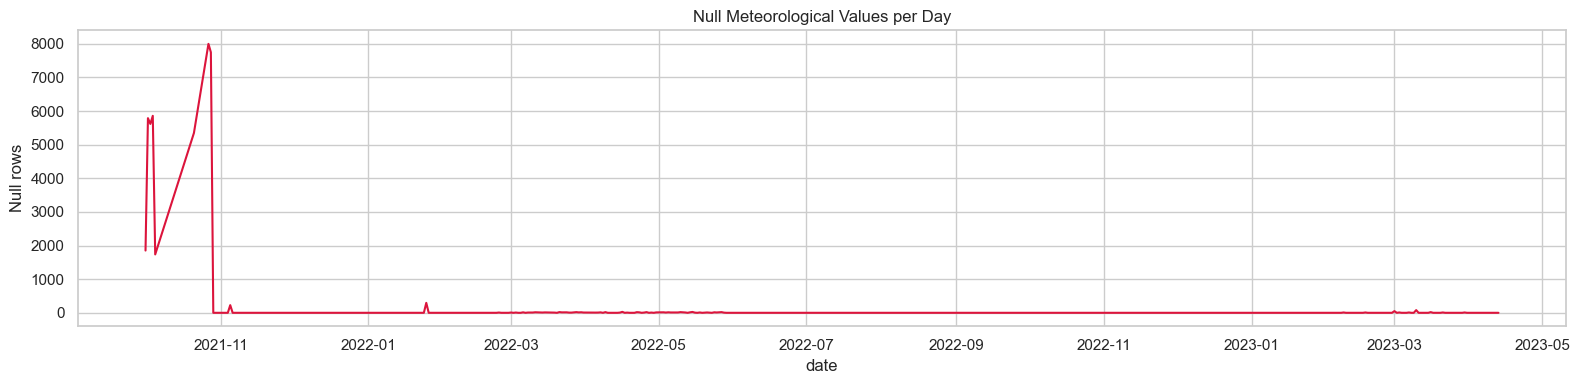

In [92]:
# Temporal pattern of nulls — when do they occur?
null_by_date = pdf.groupby("date")[METEO_COLS].apply(lambda x: x.isnull().any(axis=1).sum())
fig, ax = plt.subplots(figsize=(16, 4))
null_by_date.plot(ax=ax, color="crimson")
ax.set_title("Null Meteorological Values per Day")
ax.set_ylabel("Null rows")
plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_null_temporal.png", bbox_inches="tight")
plt.show()

In [93]:
# Are nulls concentrated at start (MNAR — dt1 started later)?
first_null_date = pdf[pdf[METEO_COLS].isnull().any(axis=1)]["date"].min()
last_null_date = pdf[pdf[METEO_COLS].isnull().any(axis=1)]["date"].max()
print(f"Null meteorological data: {first_null_date} → {last_null_date}")
print(f"Main data starts at: {pdf['date'].min()}")

# Check if nulls are ONLY at the beginning (MNAR) or scattered throughout (MAR)
null_dates = pdf[pdf[METEO_COLS].isnull().any(axis=1)]["date"].unique()
all_dates = pdf["date"].unique()
scattered_nulls = [d for d in null_dates if d > pd.Timestamp("2021-11-15").date()]
if scattered_nulls:
    print(f"\n⚠ Scattered nulls after Nov 15: {len(scattered_nulls)} days")
    print(f"  → Likely sensor dropout, NOT just the initial 27-day gap")
else:
    print(f"\n✓ Nulls only in the initial gap period — safe to trim")

Null meteorological data: 2021-10-01 → 2023-03-30
Main data starts at: 2021-10-01

⚠ Scattered nulls after Nov 15: 73 days
  → Likely sensor dropout, NOT just the initial 27-day gap


## 4. Target (Fault) Distribution & Temporal Structure

Questions:
- How severely imbalanced is it?
- How long do fault episodes last?
- Are faults clustered in time or randomly distributed?
- Do certain faults co-occur with specific weather conditions?

In [94]:
# Class distribution
fault_counts = pdf[LABEL_COL].value_counts().sort_index()
fault_pcts = (fault_counts / len(pdf) * 100).round(3)
fault_df = pd.DataFrame({"count": fault_counts, "pct": fault_pcts})
print("=== Fault Distribution ===")
print(fault_df.to_string())

binary_normal = (pdf[LABEL_COL] == 0.0).sum()
binary_fault = (pdf[LABEL_COL] != 0.0).sum()
print(f"\nBinary: Normal={binary_normal:,} ({binary_normal/len(pdf)*100:.2f}%), "
      f"Fault={binary_fault:,} ({binary_fault/len(pdf)*100:.2f}%)")
print(f"Imbalance ratio: 1:{binary_normal/binary_fault:.0f}")

=== Fault Distribution ===
         count     pct
Fault                 
0.0    2904289  97.172
1.0       6318   0.211
2.1       2148   0.072
2.2       2460   0.082
2.3       3287   0.110
3.1       2717   0.091
3.2       6292   0.211
4.0      61297   2.051

Binary: Normal=2,904,289 (97.17%), Fault=84,525 (2.83%)
Imbalance ratio: 1:34


### Understanding class imbalance

**What is class imbalance?** When one class vastly outnumbers the others. In our data:
- ~97% of rows are "Normal" (Fault = 0.0)
- ~3% are various fault types

**Why is this a problem?** If a model just predicts "Normal" for everything, it gets 97% accuracy — but it's useless for detecting faults! This is why we use metrics like **PR-AUC** (Precision-Recall Area Under Curve) and **F1-score** instead of accuracy.

**Imbalance ratio 1:N** means for every 1 fault sample, there are N normal samples.

```python
pdf[LABEL_COL].value_counts()           # Count occurrences of each unique value
.sort_index()                           # Sort by the fault code (0.0, 1.0, 2.1, ...)
(fault_counts / len(pdf) * 100)         # Convert counts to percentages
```

**The `.value_counts()` method** is one of the most useful Pandas methods. It counts how many times each unique value appears in a Series, sorted by frequency (most common first).

### Understanding fault episode analysis

```python
pdf[LABEL_COL].ne(pdf[LABEL_COL].shift())   # .ne() means "not equal"
                                              # .shift() shifts all values down by 1 row
                                              # Together: True where Fault label CHANGES
.cumsum()                                     # Cumulative sum: each "True" increments a counter
                                              # Result: each contiguous block gets a unique ID
```

**What this does:** Imagine the Fault column is: `[0, 0, 4, 4, 4, 0, 0, 1, 0]`
- After `.ne(.shift())`: `[True, False, True, False, False, True, False, True, True]`
- After `.cumsum()`: `[1, 1, 2, 2, 2, 3, 3, 4, 5]`

Now each contiguous block has a unique ID. We can `groupby` this ID to analyze each episode: when it started, how long it lasted, how many samples it contains.

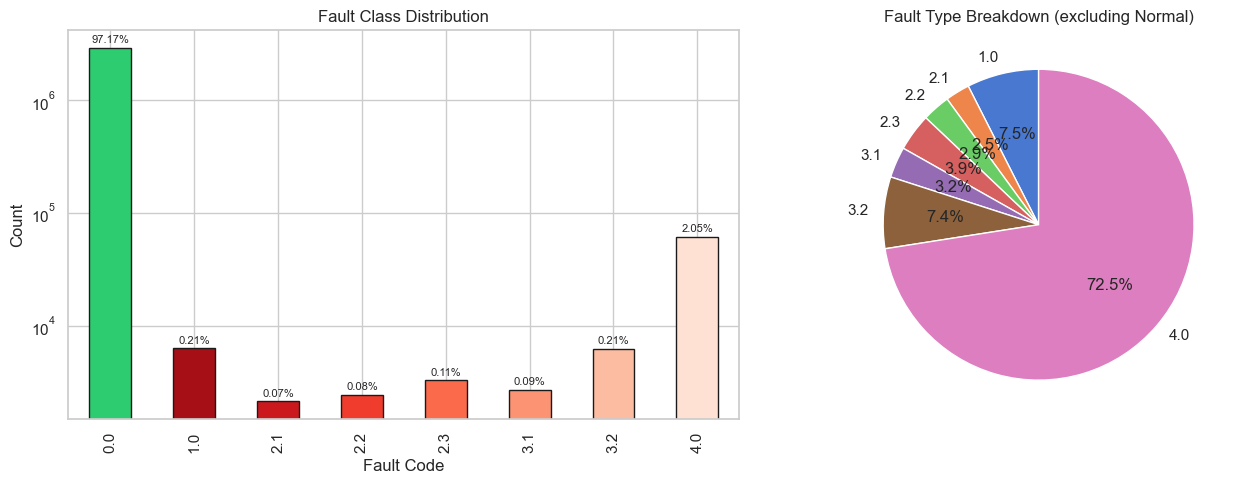

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ["#2ecc71"] + sns.color_palette("Reds_r", len(fault_counts) - 1)
fault_counts.plot(kind="bar", ax=axes[0], color=colors, edgecolor="k")
axes[0].set_title("Fault Class Distribution")
axes[0].set_xlabel("Fault Code")
axes[0].set_ylabel("Count")
axes[0].set_yscale("log")
for i, (v, p) in enumerate(zip(fault_counts.values, fault_pcts.values)):
    axes[0].text(i, v * 1.1, f"{p:.2f}%", ha="center", fontsize=8)

# Pie chart (fault classes only, excluding Normal)
fault_only = fault_counts[fault_counts.index != 0.0]
fault_only.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Fault Type Breakdown (excluding Normal)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_fault_distribution.png", bbox_inches="tight")
plt.show()

In [96]:
# Fault episode analysis — how long does each fault event last?
# Detect transitions: where Fault value changes OR segment changes (gap boundary)
label_change = pdf[LABEL_COL].ne(pdf[LABEL_COL].shift())
segment_change = pdf["segment_id"].ne(pdf["segment_id"].shift())
fault_transitions = (label_change | segment_change).cumsum()

episodes = pdf.groupby(fault_transitions).agg(
    fault_code=(LABEL_COL, "first"),
    segment=("segment_id", "first"),
    start_time=(TIME_COL, "first"),
    end_time=(TIME_COL, "last"),
    n_samples=(LABEL_COL, "count"),
).reset_index(drop=True)

# Compute duration
episodes["duration_s"] = (episodes["end_time"] - episodes["start_time"]).dt.total_seconds()
fault_episodes = episodes[episodes["fault_code"] != 0.0]

print(f"=== Fault Episode Analysis (segment-aware) ===")
print(f"Total episodes: {len(episodes):,} (Normal: {len(episodes) - len(fault_episodes):,}, Fault: {len(fault_episodes):,})")
print(f"\nFault episode durations (seconds):")
print(fault_episodes.groupby("fault_code")["duration_s"].describe().round(1).to_string())

=== Fault Episode Analysis (segment-aware) ===
Total episodes: 505 (Normal: 476, Fault: 29)

Fault episode durations (seconds):
            count     mean     std      min      25%      50%      75%      max
fault_code                                                                     
1.0           2.0  16102.0  1400.1  15112.0  15607.0  16102.0  16597.0  17092.0
2.1           1.0  10734.0     NaN  10734.0  10734.0  10734.0  10734.0  10734.0
2.2           1.0  12294.0     NaN  12294.0  12294.0  12294.0  12294.0  12294.0
2.3           1.0  16431.0     NaN  16431.0  16431.0  16431.0  16431.0  16431.0
3.1           3.0   7250.7   160.3   7128.0   7160.0   7192.0   7312.0   7432.0
3.2           4.0   8559.5  2239.4   6175.0   7209.2   8334.0   9684.2  11395.0
4.0          11.0  31395.9  7397.8  16374.0  30795.0  33433.0  34091.0  40159.0


Timezone info: UTC  →  La Réunion = UTC+4


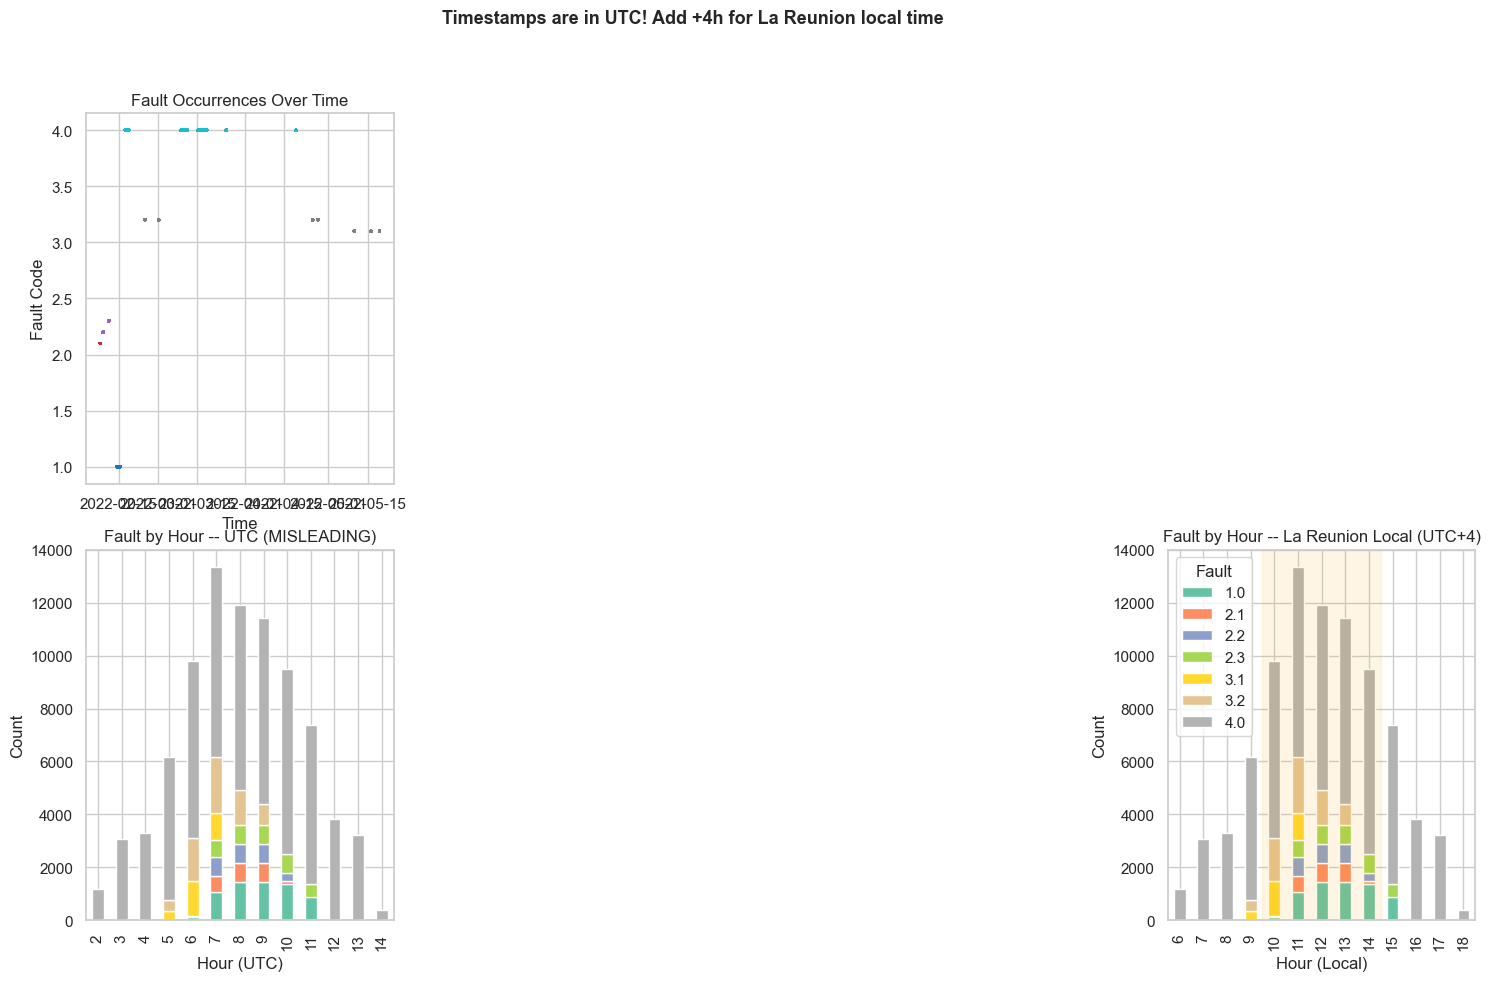

UTC 2:00  = Local 6:00  -> sunrise
UTC 7:00  = Local 11:00 -> late morning, peak production starting
UTC 8-9   = Local 12-13 -> PEAK irradiance, most faults detected here
UTC 14:00 = Local 18:00 -> sunset, faults peter out


In [97]:
# Temporal distribution of faults — when do they happen?
pdf_faults = pdf[pdf[LABEL_COL] != 0.0].copy()

# === Timezone correction ===
# Timestamps are in UTC, but La Réunion is UTC+4
print(f"Timezone info: {pdf[TIME_COL].dt.tz}  →  La Réunion = UTC+4")
pdf_faults["hour"] = pdf_faults[TIME_COL].dt.hour
pdf_faults["hour_local"] = (pdf_faults["hour"] + 4) % 24

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top left: Timeline of fault occurrences
axes[0, 0].scatter(pdf_faults[TIME_COL], pdf_faults[LABEL_COL],
                   s=1, alpha=0.3, c=pdf_faults[LABEL_COL], cmap="tab10")
axes[0, 0].set_title("Fault Occurrences Over Time")
axes[0, 0].set_ylabel("Fault Code")
axes[0, 0].set_xlabel("Time")

# Top right: empty → span the timeline across full width? use it for fault episode durations
axes[0, 1].set_visible(False)
axes[0, 0].set_position([0.05, 0.55, 0.90, 0.38])  # span full width

# Bottom left: UTC (misleading)
fault_hour_utc = pdf_faults.groupby(["hour", LABEL_COL]).size().unstack(fill_value=0)
fault_hour_utc.plot(kind="bar", stacked=True, ax=axes[1, 0], colormap="Set2", legend=False)
axes[1, 0].set_title("Fault by Hour -- UTC (MISLEADING)")
axes[1, 0].set_xlabel("Hour (UTC)")
axes[1, 0].set_ylabel("Count")

# Bottom right: Local time (correct)
fault_hour_local = pdf_faults.groupby(["hour_local", LABEL_COL]).size().unstack(fill_value=0)
fault_hour_local.plot(kind="bar", stacked=True, ax=axes[1, 1], colormap="Set2")
axes[1, 1].set_title("Fault by Hour -- La Reunion Local (UTC+4)")
axes[1, 1].set_xlabel("Hour (Local)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].axvspan(10 - fault_hour_local.index.min() - 0.5, 14 - fault_hour_local.index.min() + 0.5,
                   alpha=0.1, color="orange", label="Peak irradiance")

plt.suptitle("Timestamps are in UTC! Add +4h for La Reunion local time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_fault_temporal.png", bbox_inches="tight")
plt.show()

print("UTC 2:00  = Local 6:00  -> sunrise")
print("UTC 7:00  = Local 11:00 -> late morning, peak production starting")
print("UTC 8-9   = Local 12-13 -> PEAK irradiance, most faults detected here")
print("UTC 14:00 = Local 18:00 -> sunset, faults peter out")

## 5. Day/Night Segmentation

Solar panels produce nothing at night (GTI ≈ 0). Night-time "normal" data has different statistics from daytime "normal" data. Key question: **should the model see night data?**

- For **anomaly detection (Task A):** night data is trivially normal → inflates accuracy. Better to filter to daytime-only for training and evaluation.
- For **fault classification (Task B):** some faults are only detectable during production.
- For **forecasting (Task C):** need sunrise/sunset transitions.

**Recommendation:** Flag daytime rows. Primary metrics computed on daytime-only.

In [98]:
# Irradiance-based day/night split
# GTI > 10 W/m² is a common threshold for "meaningful solar production"
GTI_THRESHOLD = 10.0

# Handle nulls in GTI (initial 27-day gap)
pdf["is_daytime"] = pdf["GTI"].fillna(0) > GTI_THRESHOLD
day_counts = pdf["is_daytime"].value_counts()
print(f"=== Day/Night Split ===")
print(f"Daytime (GTI > {GTI_THRESHOLD}): {day_counts.get(True, 0):,} rows ({day_counts.get(True, 0)/len(pdf)*100:.1f}%)")
print(f"Night   (GTI ≤ {GTI_THRESHOLD}): {day_counts.get(False, 0):,} rows ({day_counts.get(False, 0)/len(pdf)*100:.1f}%)")

=== Day/Night Split ===
Daytime (GTI > 10.0): 2,937,653 rows (98.3%)
Night   (GTI ≤ 10.0): 51,161 rows (1.7%)


In [99]:
# Fault distribution: daytime vs night
fault_day = pdf[pdf["is_daytime"]][LABEL_COL].value_counts()
fault_night = pdf[~pdf["is_daytime"]][LABEL_COL].value_counts()
compare_dn = pd.DataFrame({"daytime": fault_day, "night": fault_night}).fillna(0).astype(int)
print("\nFault counts: daytime vs night")
print(compare_dn.to_string())
print(f"\n→ Faults during daytime: {(pdf[LABEL_COL] != 0.0) [pdf['is_daytime']].sum():,}")
print(f"→ Faults during night:   {(pdf[LABEL_COL] != 0.0) [~pdf['is_daytime']].sum():,}")


Fault counts: daytime vs night
       daytime  night
Fault                
0.0    2853212  51077
1.0       6318      0
2.1       2148      0
2.2       2460      0
2.3       3287      0
3.1       2707     10
3.2       6292      0
4.0      61223     74

→ Faults during daytime: 84,441
→ Faults during night:   84


## 6. Univariate Distributions — Normal vs Fault

For each feature, compare the distribution under normal conditions vs each fault type. Large differences → discriminative features → good for classification. No difference → feature won't help → candidate for removal.

In [100]:
# Distribution comparison: Normal vs Fault (binary)
pdf["is_fault"] = (pdf[LABEL_COL] != 0.0).astype(int)

# Only use daytime data with non-null features for meaningful comparison
pdf_day = pdf[pdf["is_daytime"] & pdf[FEATURE_COLS].notna().all(axis=1)].copy()
print(f"Daytime complete rows for analysis: {len(pdf_day):,}")

Daytime complete rows for analysis: 2,937,643


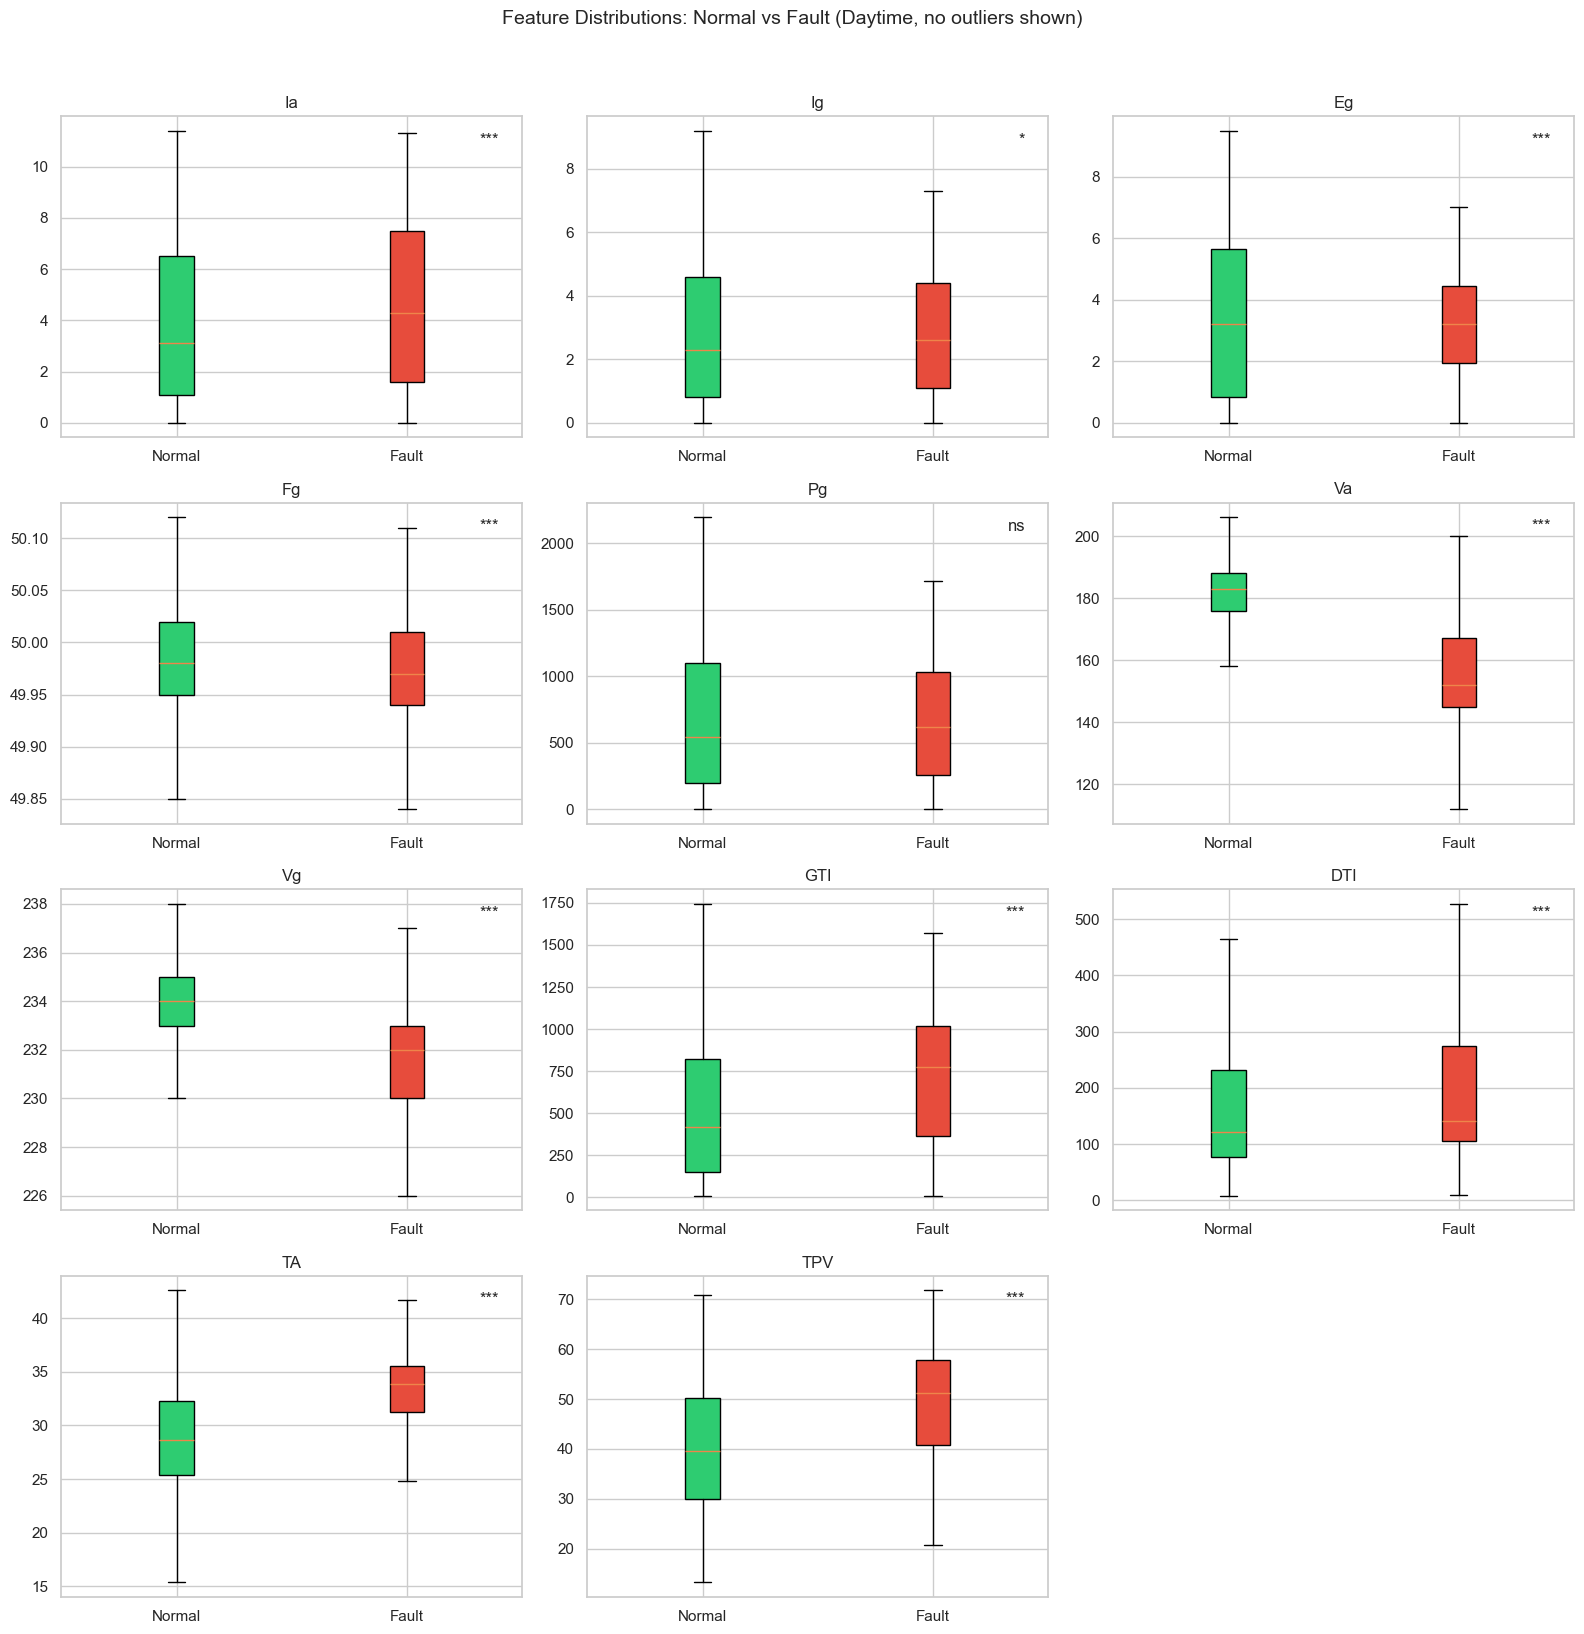

In [101]:
# Box plots: each feature by fault status (binary)
n_features = len(FEATURE_COLS)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(FEATURE_COLS):
    data_normal = pdf_day.loc[pdf_day["is_fault"] == 0, col].dropna()
    data_fault = pdf_day.loc[pdf_day["is_fault"] == 1, col].dropna()

    bp = axes[i].boxplot(
        [data_normal.values, data_fault.values],
        tick_labels=["Normal", "Fault"],
        patch_artist=True,
        showfliers=False,  # hide outliers for cleaner view
    )
    bp["boxes"][0].set_facecolor("#2ecc71")
    bp["boxes"][1].set_facecolor("#e74c3c")
    axes[i].set_title(col)

    # Mann-Whitney U test (non-parametric)
    if len(data_fault) > 10:
        stat, pval = stats.mannwhitneyu(data_normal, data_fault, alternative="two-sided")
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
        axes[i].text(0.95, 0.95, sig, transform=axes[i].transAxes, ha="right", va="top", fontsize=12)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions: Normal vs Fault (Daytime, no outliers shown)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_boxplots_normal_vs_fault.png", bbox_inches="tight")
plt.show()

### Understanding box plots and the Mann-Whitney U test

**What is a box plot?** A compact way to show a distribution:
```
         ┌──────┐
    ─────┤      ├─────
         └──┬───┘
            │
  whisker  Q1  median  Q3  whisker
```
- The **box** spans Q1 to Q3 (middle 50% of data = IQR)
- The **line inside** the box = median
- **Whiskers** extend to 1.5×IQR beyond the box
- Dots beyond whiskers = **outliers** (we hide them with `showfliers=False` for cleaner plots)

**Why compare Normal vs Fault?** If the box plots for Normal and Fault look very different for a feature (e.g., "Pg"), that feature is **discriminative** — it helps distinguish faults from normal behavior. If they look identical, that feature is useless for classification.

**Mann-Whitney U Test** — a non-parametric statistical test:
- **Non-parametric** = doesn't assume data follows a normal (bell curve) distribution (good for us — PV data is NOT normally distributed)
- **Null hypothesis (H0):** The two groups (Normal, Fault) come from the same distribution
- **Alternative:** They come from different distributions
- **p-value interpretation:**
  - `***` (p < 0.001): overwhelmingly significant difference
  - `**` (p < 0.01): very significant
  - `*` (p < 0.05): significant
  - `ns` (p ≥ 0.05): not significant — feature doesn't discriminate

```python
stats.mannwhitneyu(data_normal, data_fault, alternative="two-sided")
```
Returns `(U_statistic, p_value)`. We only use the p-value.

**What is `patch_artist=True`?** It fills the box with color instead of leaving it empty. **`tick_labels`** sets the text under each box.

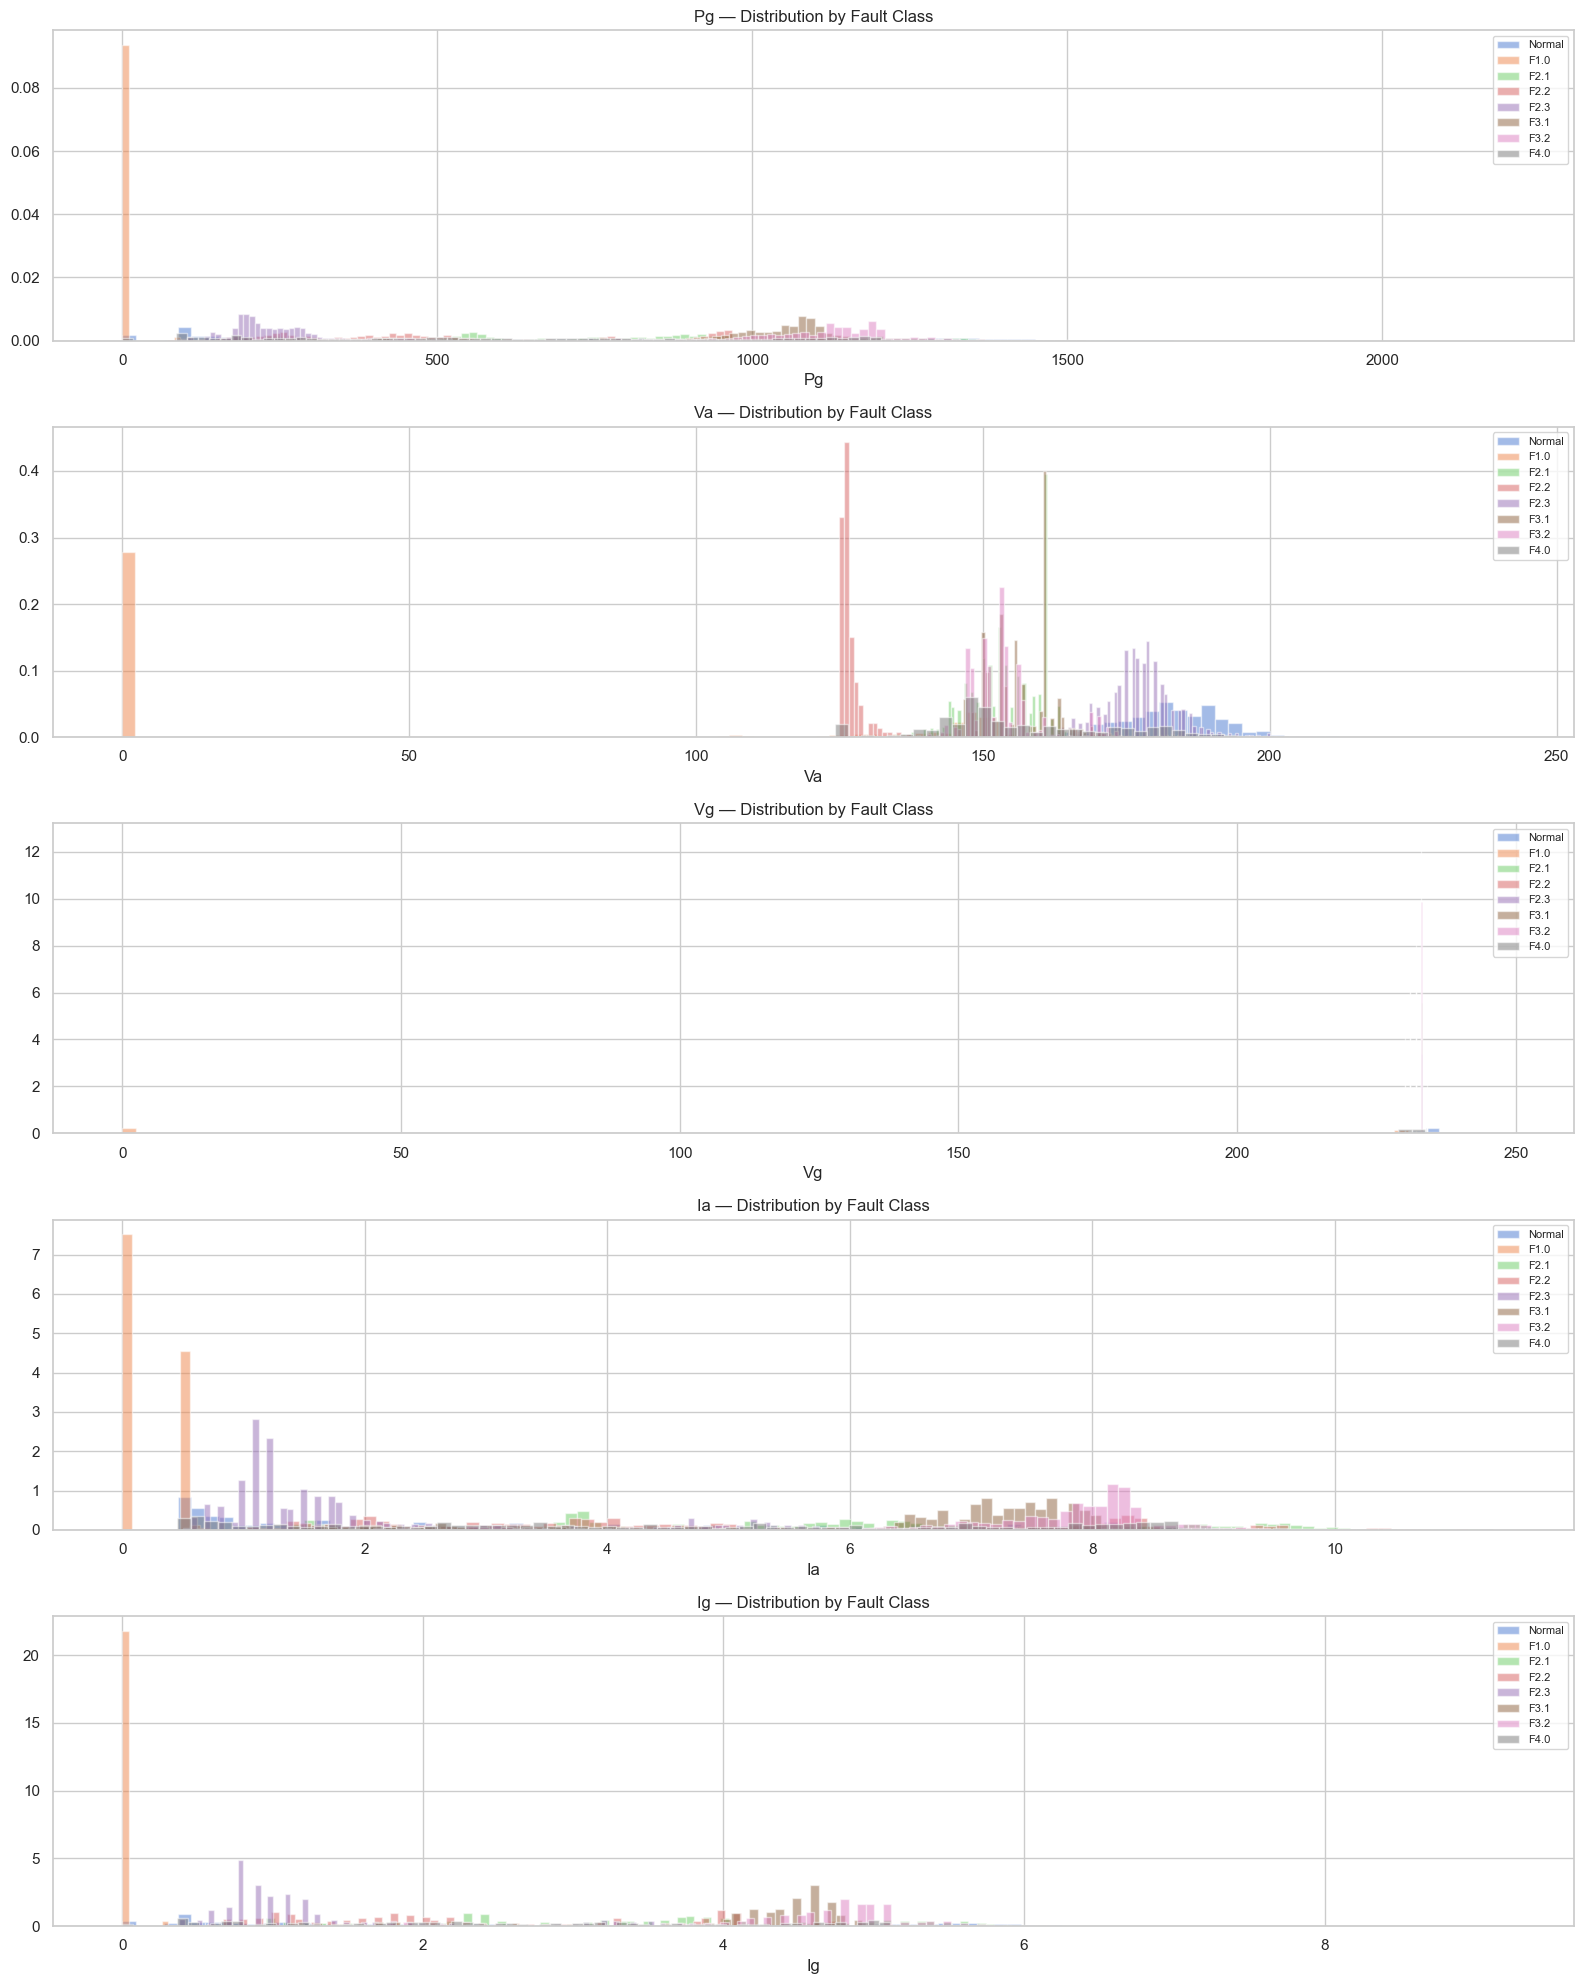

In [102]:
# Per-fault-class distributions for top discriminative features
# Focus on the most promising: Pg, Va, Vg, Ia, Ig
KEY_FEATURES = ["Pg", "Va", "Vg", "Ia", "Ig"]

fig, axes = plt.subplots(len(KEY_FEATURES), 1, figsize=(16, 4 * len(KEY_FEATURES)))
for i, col in enumerate(KEY_FEATURES):
    for fc in sorted(pdf_day[LABEL_COL].unique()):
        subset = pdf_day[pdf_day[LABEL_COL] == fc][col].dropna()
        if len(subset) > 100:
            label = f"F{fc}" if fc != 0.0 else "Normal"
            axes[i].hist(subset, bins=100, alpha=0.5, label=label, density=True)
    axes[i].set_title(f"{col} — Distribution by Fault Class")
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_class_conditional_dists.png", bbox_inches="tight")
plt.show()

## 7. Correlation & Collinearity Analysis

**Where collinearity fits in the pipeline:**
- **Before feature engineering:** check raw feature redundancy to avoid multiplying redundant derived features (e.g., if Ia ≈ Ig, then dIa/dt ≈ dIg/dt → double waste)
- **After feature engineering:** re-check on the full feature set to decide what to drop

**Why it matters:**
- High collinearity inflates variance in linear models and some tree models
- Wastes compute in DL models (redundant channels)
- Makes feature importance unreliable (importance splits between correlated features)

**VIF > 10** = serious multicollinearity. **VIF > 5** = moderate concern.

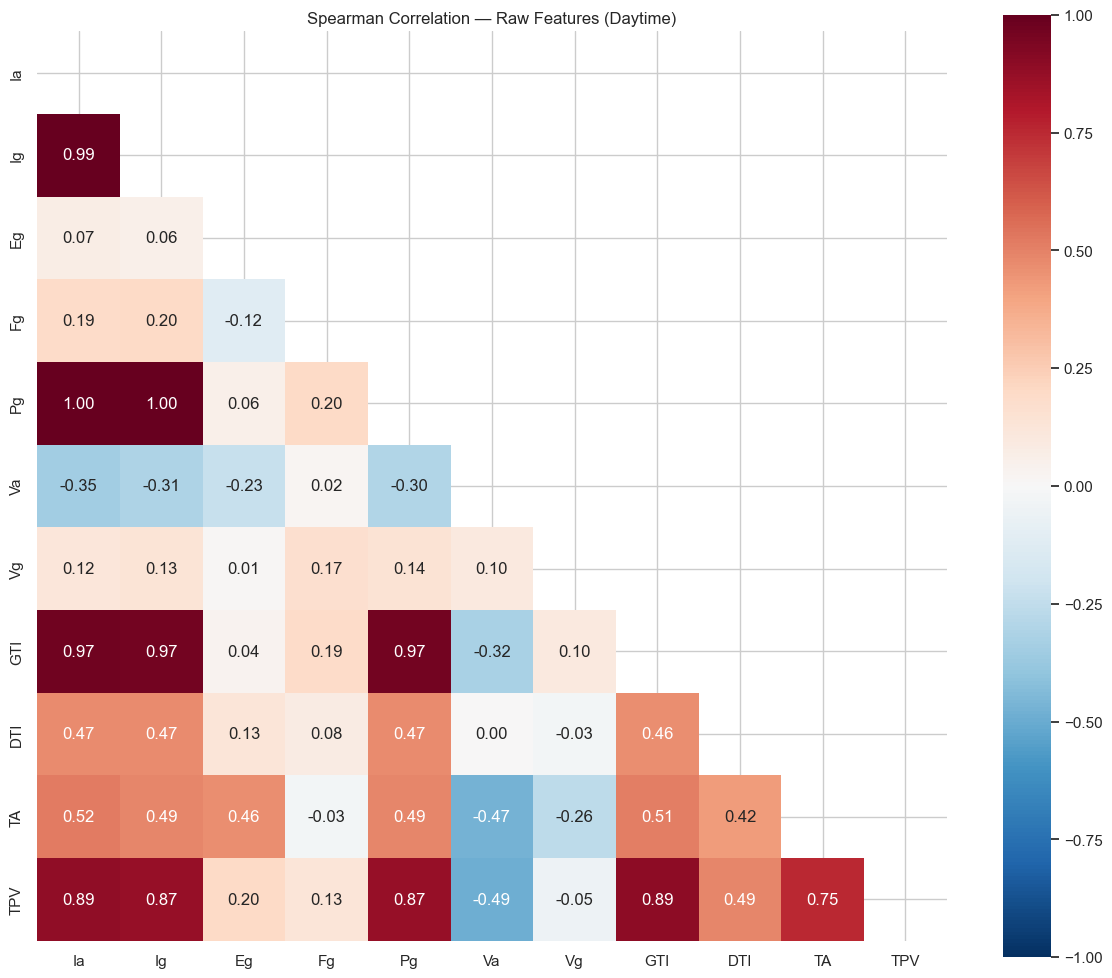

In [103]:
# Spearman correlation matrix (daytime, complete rows)
corr_matrix = pdf_day[FEATURE_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Spearman Correlation — Raw Features (Daytime)")
plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

### Understanding Spearman Correlation

**Why Spearman instead of Pearson?**
- **Pearson** measures **linear** relationships only (assumes both variables change at a constant rate relative to each other)
- **Spearman** measures **monotonic** relationships — if X goes up, Y goes up (or down), but not necessarily at a constant rate
- PV data has non-linear sensor dynamics (e.g., power vs irradiance follows a curve, not a straight line), so Spearman is more appropriate

**How it works:** Spearman converts values to **ranks** first, then computes Pearson on the ranks:

$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

where $d_i$ = difference between ranks of $x_i$ and $y_i$.

- $\rho = +1$: perfect monotonic increase (X up → Y always up, in any curve shape)
- $\rho = -1$: perfect monotonic decrease
- $\rho = 0$: no monotonic relationship

**The heatmap** shows ALL pairwise Spearman correlations. Red = positive, Blue = negative, White = zero.

```python
pdf_day[FEATURE_COLS].corr(method="spearman")   # Computes the 11×11 rank correlation matrix
```

```python
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
```
Creates an upper-triangular mask of True values. Since `corr(A,B) = corr(B,A)`, we only need the lower triangle — the upper half is redundant. The mask hides it.

**Why do we care about correlation here?**
- If two features are highly correlated (|ρ| > 0.85), they carry nearly the same information
- Example: if `Ia` (array current) and `Ig` (grid current) have ρ = 0.99, including both is wasteful
- This leads us to **VIF analysis** (next cell) for a more rigorous test

In [104]:
# Highly correlated pairs (|ρ| > 0.85)
high_corr_pairs = []
for i in range(len(FEATURE_COLS)):
    for j in range(i + 1, len(FEATURE_COLS)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr_pairs.append((FEATURE_COLS[i], FEATURE_COLS[j], round(r, 3)))

print("=== Highly Correlated Pairs (|ρ| > 0.85) ===")
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f"  {f1:5s} ↔ {f2:5s}  ρ = {r:+.3f}")

if not high_corr_pairs:
    print("  (none found)")

=== Highly Correlated Pairs (|ρ| > 0.85) ===
  Ig    ↔ Pg     ρ = +0.999
  Ia    ↔ Ig     ρ = +0.995
  Ia    ↔ Pg     ρ = +0.995
  Ia    ↔ GTI    ρ = +0.971
  Ig    ↔ GTI    ρ = +0.968
  Pg    ↔ GTI    ρ = +0.968
  GTI   ↔ TPV    ρ = +0.894
  Ia    ↔ TPV    ρ = +0.885
  Ig    ↔ TPV    ρ = +0.869
  Pg    ↔ TPV    ρ = +0.868


In [105]:
# Variance Inflation Factor (VIF)
# VIF_j = 1 / (1 - R²_j) where R²_j is from regressing feature j on all others
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Use daytime complete data, subsample for speed
vif_data = pdf_day[FEATURE_COLS].dropna()
if len(vif_data) > 50_000:
    vif_data = vif_data.sample(50_000, random_state=42)

# Standardize (VIF is scale-dependent)
vif_scaled = pd.DataFrame(
    StandardScaler().fit_transform(vif_data),
    columns=FEATURE_COLS,
)

vif_results = pd.DataFrame({
    "feature": FEATURE_COLS,
    "VIF": [variance_inflation_factor(vif_scaled.values, i) for i in range(len(FEATURE_COLS))],
}).sort_values("VIF", ascending=False)

print("=== Variance Inflation Factor ===")
print(vif_results.to_string(index=False))
print(f"\n{'⚠ Severe multicollinearity detected' if (vif_results['VIF'] > 10).any() else '✓ No severe multicollinearity'}")
print("VIF > 10 = severe | VIF > 5 = moderate | VIF < 5 = acceptable")

=== Variance Inflation Factor ===
feature         VIF
     Ig 3474.108552
     Pg 3432.134757
     Ia  159.057532
     Vg   39.099519
     Fg   38.129298
    GTI   18.460137
    TPV   11.150186
     TA    4.149522
     Va    2.404193
     Eg    1.505881
    DTI    1.290645

⚠ Severe multicollinearity detected
VIF > 10 = severe | VIF > 5 = moderate | VIF < 5 = acceptable


### Understanding Variance Inflation Factor (VIF)

**The problem with just looking at pairwise correlations:** Feature A might not be highly correlated with B or C individually, but might be *perfectly predicted by B + C together*. Pairwise correlation misses this.

**VIF catches this.** For each feature $X_j$:
1. Regress $X_j$ on ALL other features: $X_j = \beta_0 + \beta_1 X_1 + ... + \beta_k X_k$
2. Get the $R^2$ of this regression (how well the other features predict $X_j$)
3. $VIF_j = \frac{1}{1 - R^2_j}$

**Interpretation:**
- $VIF = 1$: feature is completely independent of all others (ideal)
- $VIF = 5$: moderately redundant — 80% of its variance is explained by other features
- $VIF = 10$: severely redundant — 90% explained
- $VIF > 10$: **multicollinearity** — this feature is almost a linear combination of others

**Why standardize first?**
```python
StandardScaler().fit_transform(vif_data)
```
StandardScaler transforms each feature to have mean=0 and std=1:
$$z = \frac{x - \mu}{\sigma}$$
VIF results can be misleading if features have wildly different scales (e.g., power in Watts vs temperature in °C).

**Why subsample?**
```python
if len(vif_data) > 50_000:
    vif_data = vif_data.sample(50_000, random_state=42)
```
VIF requires fitting a linear regression for each feature. With 2 million rows, this is slow. 50K rows gives statistically equivalent results in seconds. `random_state=42` ensures reproducibility (same sample every time).

## 8. Mutual Information with Target

Mutual Information (MI) measures the **non-linear** dependency between a feature and the target. Unlike correlation (linear only), MI captures any functional relationship.

High MI → feature is informative for classification.  
MI ≈ 0 → feature is independent of target.

In [106]:
from sklearn.feature_selection import mutual_info_classif

# Subsample for speed
mi_data = pdf_day[FEATURE_COLS + [LABEL_COL]].dropna()
if len(mi_data) > 100_000:
    mi_sample = mi_data.sample(100_000, random_state=42)
else:
    mi_sample = mi_data

X_mi = mi_sample[FEATURE_COLS].values
# Binary target for Task A context
y_mi_binary = (mi_sample[LABEL_COL].values != 0.0).astype(int)
# Multi-class target for Task B context
y_mi_multi = mi_sample[LABEL_COL].values.astype(int)

mi_binary = mutual_info_classif(X_mi, y_mi_binary, random_state=42, n_neighbors=5)
mi_multi = mutual_info_classif(X_mi, y_mi_multi, random_state=42, n_neighbors=5)

mi_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "MI_binary_anomaly": mi_binary,
    "MI_multiclass_fault": mi_multi,
}).sort_values("MI_binary_anomaly", ascending=False)

print("=== Mutual Information with Target ===")
print(mi_df.to_string(index=False))

=== Mutual Information with Target ===
feature  MI_binary_anomaly  MI_multiclass_fault
     Va           0.052834             0.060263
     Vg           0.024418             0.030044
     Eg           0.018569             0.030103
     TA           0.015427             0.019555
    DTI           0.009606             0.013450
    TPV           0.009235             0.013149
    GTI           0.006233             0.009621
     Ia           0.006131             0.014712
     Pg           0.005229             0.014359
     Fg           0.004998             0.008820
     Ig           0.004622             0.013222


### Understanding Mutual Information (MI)

**The limitation of correlation:** Correlation only measures LINEAR relationships. If a feature has a complex, non-linear relationship with the target (e.g., a U-shape), correlation says r ≈ 0 — "no relationship" — which is WRONG.

**Mutual Information** fixes this. It measures ANY kind of statistical dependency:

$$MI(X; Y) = \sum_{x,y} p(x,y) \log\frac{p(x,y)}{p(x)p(y)}$$

In plain English: MI asks *"How much does knowing X reduce my uncertainty about Y?"*
- $MI = 0$: X and Y are completely independent — knowing X tells you nothing about Y
- $MI > 0$: X carries information about Y. Higher = more informative.
- MI is **always ≥ 0** (unlike correlation which can be negative)

**scikit-learn's `mutual_info_classif`:**
```python
mutual_info_classif(X, y, random_state=42, n_neighbors=5)
```
- Uses a **k-nearest neighbors** approach to estimate MI continuously
- `n_neighbors=5`: each point's local density is estimated using its 5 nearest neighbors
- Returns an array of MI values, one per feature

**Why do we compute MI twice (binary and multi-class)?**
- **Binary** (`y_mi_binary`): Normal vs Fault (0 vs 1) — for Task A (anomaly detection)
- **Multi-class** (`y_mi_multi`): 0 vs 1 vs 2.1 vs 2.2 vs ... — for Task B (fault classification)

A feature might be great for detecting *any* fault (high binary MI) but bad at distinguishing *which* fault (low multi-class MI), or vice versa.

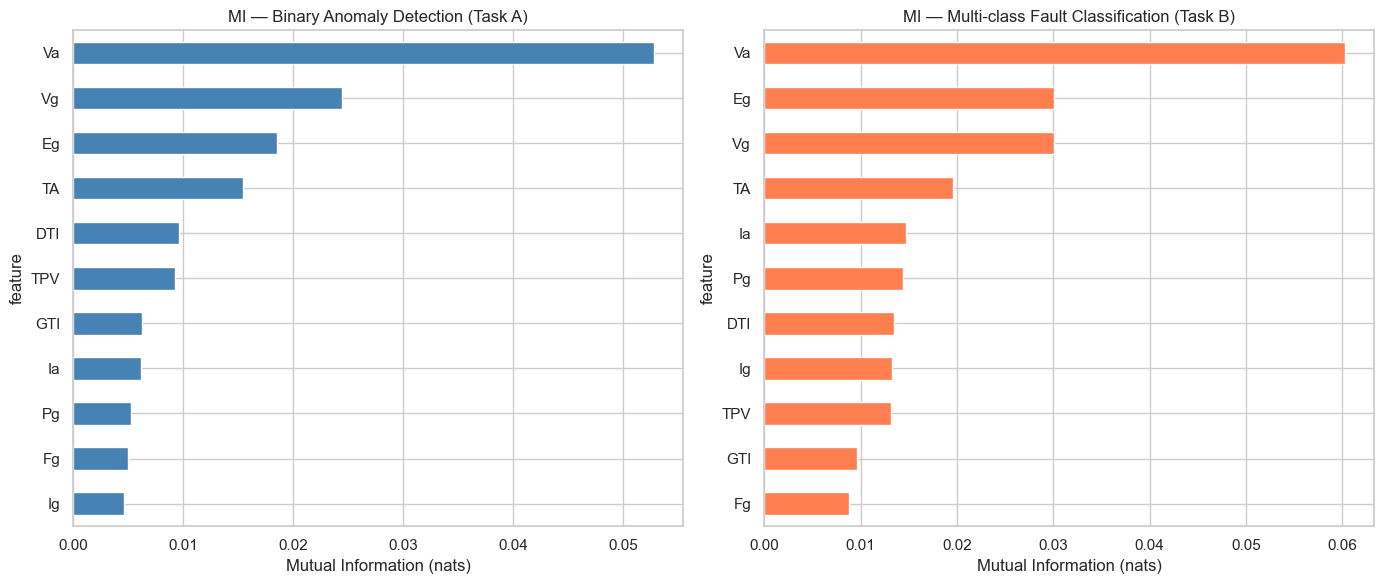

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
mi_df.sort_values("MI_binary_anomaly").plot(
    kind="barh", x="feature", y="MI_binary_anomaly", ax=axes[0], color="steelblue", legend=False)
axes[0].set_title("MI — Binary Anomaly Detection (Task A)")
axes[0].set_xlabel("Mutual Information (nats)")

mi_df.sort_values("MI_multiclass_fault").plot(
    kind="barh", x="feature", y="MI_multiclass_fault", ax=axes[1], color="coral", legend=False)
axes[1].set_title("MI — Multi-class Fault Classification (Task B)")
axes[1].set_xlabel("Mutual Information (nats)")

plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_mutual_information.png", bbox_inches="tight")
plt.show()

## 9. Outlier Analysis

Outliers in PV data can be:
- **Real fault signatures** → must NOT be removed (they ARE the signal!)
- **Sensor errors** → must be flagged/removed
- **Operational transients** → e.g., inverter startup/shutdown spikes

Strategy: Compute outlier counts, but only flag as "suspect" if they occur during NORMAL-labeled periods (outliers during faults are expected).

In [108]:
# IQR-based outlier detection
outlier_report = {}
for col in FEATURE_COLS:
    series = pdf_day[col].dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 3 * iqr, q3 + 3 * iqr  # 3×IQR = extreme outliers only
    n_outliers = ((series < lower) | (series > upper)).sum()

    # Outliers during normal periods (potentially sensor errors)
    normal_series = pdf_day.loc[pdf_day[LABEL_COL] == 0.0, col].dropna()
    n_normal_outliers = ((normal_series < lower) | (normal_series > upper)).sum()

    outlier_report[col] = {
        "total_outliers_3iqr": n_outliers,
        "normal_period_outliers": n_normal_outliers,
        "pct_outlier": round(n_outliers / len(series) * 100, 3),
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
    }

outlier_df = pd.DataFrame(outlier_report).T
print("=== Outlier Report (3×IQR, Daytime) ===")
print(outlier_df.to_string())
print(f"\n→ 'normal_period_outliers' = potential sensor errors (outliers when Fault=0)")

=== Outlier Report (3×IQR, Daytime) ===
     total_outliers_3iqr  normal_period_outliers  pct_outlier  lower_bound  upper_bound
Ia                   0.0                     0.0        0.000       -15.10        22.70
Ig                   0.0                     0.0        0.000       -10.60        16.00
Eg                   0.0                     0.0        0.000       -13.39        19.85
Fg                5408.0                  1590.0        0.184        49.74        50.23
Pg                   0.0                     0.0        0.000     -2479.00      3772.00
Va               23584.0                 12839.0        0.803       136.00       227.00
Vg                5531.0                  1615.0        0.188       227.00       241.00
GTI                  0.0                     0.0        0.000     -1865.80      2853.60
DTI                 49.0                    49.0        0.002      -394.16       704.07
TA                   0.0                     0.0        0.000         4.51      

### Understanding IQR-based outlier detection

**IQR (Interquartile Range)** = Q3 - Q1 (the range of the middle 50% of data).

The standard rule: a value is an **outlier** if it falls below $Q1 - k \times IQR$ or above $Q3 + k \times IQR$.
- $k = 1.5$: "mild" outliers (common in box plots)
- $k = 3$: "extreme" outliers (what we use here — very conservative, only flags truly extreme values)

**Example:** If power values have Q1=100W, Q3=500W, then IQR=400:
- Lower bound: 100 - 3×400 = -1100W (anything below is extreme)
- Upper bound: 500 + 3×400 = 1700W (anything above is extreme)

**The critical insight for PV fault detection:**
> Outliers during FAULT periods are **expected** — they ARE the fault signature! Don't remove them.
> Outliers during NORMAL periods are **suspicious** — possibly sensor errors.

That's why the code computes `normal_period_outliers` separately:
```python
normal_series = pdf_day.loc[pdf_day[LABEL_COL] == 0.0, col]  # Only Normal-labeled rows
```
If there are many outliers during normal periods, they might be:
1. Mislabeled faults (the label is wrong)
2. Sensor glitches
3. Legitimate transients (inverter startup, cloud edges)

## 10. Stationarity Diagnostics

Non-stationarity affects:
- Window-based feature extraction (assumes local stationarity)
- Time-series models (GRU/LSTM assume patterns repeat)
- Train/test validity (distribution shifts over time)

We use the Augmented Dickey-Fuller (ADF) test:
- H0: unit root (non-stationary)
- p < 0.05 → reject H0 → stationary ✓

In [109]:
from statsmodels.tsa.stattools import adfuller

# Use the LARGEST contiguous segment for ADF (must be truly sequential data)
largest_seg_id = seg_stats.loc[seg_stats["n_rows"].idxmax(), "segment_id"]
pdf_largest_seg = pdf_day[pdf_day["segment_id"] == largest_seg_id]
adf_sample = pdf_largest_seg[FEATURE_COLS].dropna().iloc[::100]  # every 100th row within segment
print(f"ADF test on largest contiguous segment (id={largest_seg_id}): {len(pdf_largest_seg):,} rows, subsampled to {len(adf_sample):,}")

adf_results = {}
for col in FEATURE_COLS:
    series = adf_sample[col].values
    try:
        adf_stat, pval, _, _, _, _ = adfuller(series, maxlag=50, autolag="AIC")
        adf_results[col] = {"ADF_stat": round(adf_stat, 3), "p_value": round(pval, 4),
                            "stationary": pval < 0.05}
    except Exception as e:
        adf_results[col] = {"ADF_stat": np.nan, "p_value": np.nan, "stationary": None, "error": str(e)}

adf_df = pd.DataFrame(adf_results).T
print("\n=== Augmented Dickey-Fuller Stationarity Test ===")
print(adf_df.to_string())
non_stationary = adf_df[adf_df["stationary"] == False]
if len(non_stationary) > 0:
    print(f"\n!! Non-stationary features: {list(non_stationary.index)}")
    print("  -> Consider differencing or detrending before windowing")
else:
    print("\n-> All features appear stationary (on largest contiguous segment)")

ADF test on largest contiguous segment (id=97): 8,180 rows, subsampled to 82

=== Augmented Dickey-Fuller Stationarity Test ===
    ADF_stat p_value stationary                                                                                                            error
Ia       NaN     NaN       None  maxlag must be less than (nobs/2 - 1 - ntrend) where n trend is the number of included deterministic regressors
Ig       NaN     NaN       None  maxlag must be less than (nobs/2 - 1 - ntrend) where n trend is the number of included deterministic regressors
Eg       NaN     NaN       None  maxlag must be less than (nobs/2 - 1 - ntrend) where n trend is the number of included deterministic regressors
Fg       NaN     NaN       None  maxlag must be less than (nobs/2 - 1 - ntrend) where n trend is the number of included deterministic regressors
Pg       NaN     NaN       None  maxlag must be less than (nobs/2 - 1 - ntrend) where n trend is the number of included deterministic regressors
Va

### Understanding Stationarity and the ADF Test

**What is stationarity?** A time series is **stationary** if its statistical properties (mean, variance) don't change over time.

**Non-stationary example:** Ice cream sales from January to August — the mean increases with summer. A model trained on January data would fail on July data because the distribution shifted.

**Stationary example:** Temperature *deviations from the monthly average* — these fluctuate around zero consistently year-round.

**Why does stationarity matter for ML?**
- If the data goes **train → val → test** in time order, and the distribution shifts over time, then:
  - Train data looks different from test data
  - Your model's accuracy on test data will be misleading
- Time-series models (LSTM, GRU) assume the patterns they learn are repeatable

**Augmented Dickey-Fuller (ADF) Test:**
- **Null hypothesis H0:** The series has a "unit root" → it's non-stationary (trending, random walk)
- **Alternative:** The series is stationary
- If **p-value < 0.05**: we reject H0 → evidence of stationarity (good!)
- If **p-value ≥ 0.05**: we cannot reject H0 → potentially non-stationary (needs differencing or detrending)

```python
adf_sample = pdf_day[FEATURE_COLS].dropna().iloc[::100]  # Take every 100th row
```
`iloc[::100]` is Python slice notation: `[start:stop:step]`. `::100` means "start at 0, go to end, step by 100" — we take 1% of the data for speed. ADF is an $O(n^2)$ algorithm — full data would take forever.

```python
adfuller(series, maxlag=50, autolag="AIC")
```
- `maxlag=50`: how many lagged values to consider in the test regression
- `autolag="AIC"`: automatically picks the best lag using the **Akaike Information Criterion** — a metric that balances model fit vs complexity

## 11. Sensor Health Checks

Look for:
- **Stuck-at values:** sensor frozen at constant reading
- **Drift:** gradual shift in baseline over months
- **Zero-power periods:** inverter shutdown (legitimate night, or fault?)

In [110]:
# Stuck-at detection: consecutive identical values (segment-aware)
stuck_report = {}
for col in FEATURE_COLS:
    all_max_runs = []
    all_mean_runs = []
    for seg_id, seg_group in pdf.groupby("segment_id"):
        series = seg_group[col].dropna()
        if len(series) < 2:
            continue
        runs = (series != series.shift()).cumsum()
        run_lengths = runs.value_counts()
        all_max_runs.append(run_lengths.max())
        all_mean_runs.append(run_lengths.mean())

    stuck_report[col] = {
        "max_consecutive_identical": int(max(all_max_runs)) if all_max_runs else 0,
        "mean_run_length": round(np.mean(all_mean_runs), 1) if all_mean_runs else 0,
        "n_unique_values": pdf[col].dropna().nunique(),
        "flagged": max(all_max_runs, default=0) > 1000,
    }

stuck_df = pd.DataFrame(stuck_report).T
print("=== Stuck-at Sensor Detection (segment-aware) ===")
print(stuck_df.to_string())
flagged = stuck_df[stuck_df["flagged"]]
if len(flagged) > 0:
    print(f"\n!! Potentially stuck sensors: {list(flagged.index)}")
else:
    print("\n-> No sensors appear stuck")

=== Stuck-at Sensor Detection (segment-aware) ===
    max_consecutive_identical mean_run_length n_unique_values flagged
Ia                       2985             4.9             111    True
Ig                       3070             3.7              91    True
Eg                       3159            17.0            9358    True
Fg                       2985             1.2             110    True
Pg                       3070             2.4            2010    True
Va                       2985             1.4             142    True
Vg                       2985             6.9              26    True
GTI                        26             1.4            7784   False
DTI                        39             1.5            5265   False
TA                         35             1.1            3157   False
TPV                        39             1.2            5767   False

!! Potentially stuck sensors: ['Ia', 'Ig', 'Eg', 'Fg', 'Pg', 'Va', 'Vg']


### Understanding stuck-at sensor detection

**What is a stuck sensor?** A sensor that reports the same value over and over — its internal mechanism froze. Example: a temperature sensor stuck at 25.0°C for 3 hours.

**How the code detects it:**
```python
runs = (series != series.shift()).cumsum()
```
This is the same "run-length encoding" trick from the fault episode analysis:
1. `series != series.shift()` → True where the value CHANGES
2. `.cumsum()` → groups consecutive identical values with the same ID
3. `runs.value_counts().max()` → length of the LONGEST run of identical values

**Threshold:** We flag sensors with >1000 consecutive identical readings. At 7s sampling, that's ~2 hours of frozen sensor — clearly abnormal.

**Why do we also check `n_unique_values`?** A sensor with very few unique values (e.g., `Fg` frequency which might only be 50.0 Hz) could legitimately repeat. High unique count + long runs = definitely stuck.

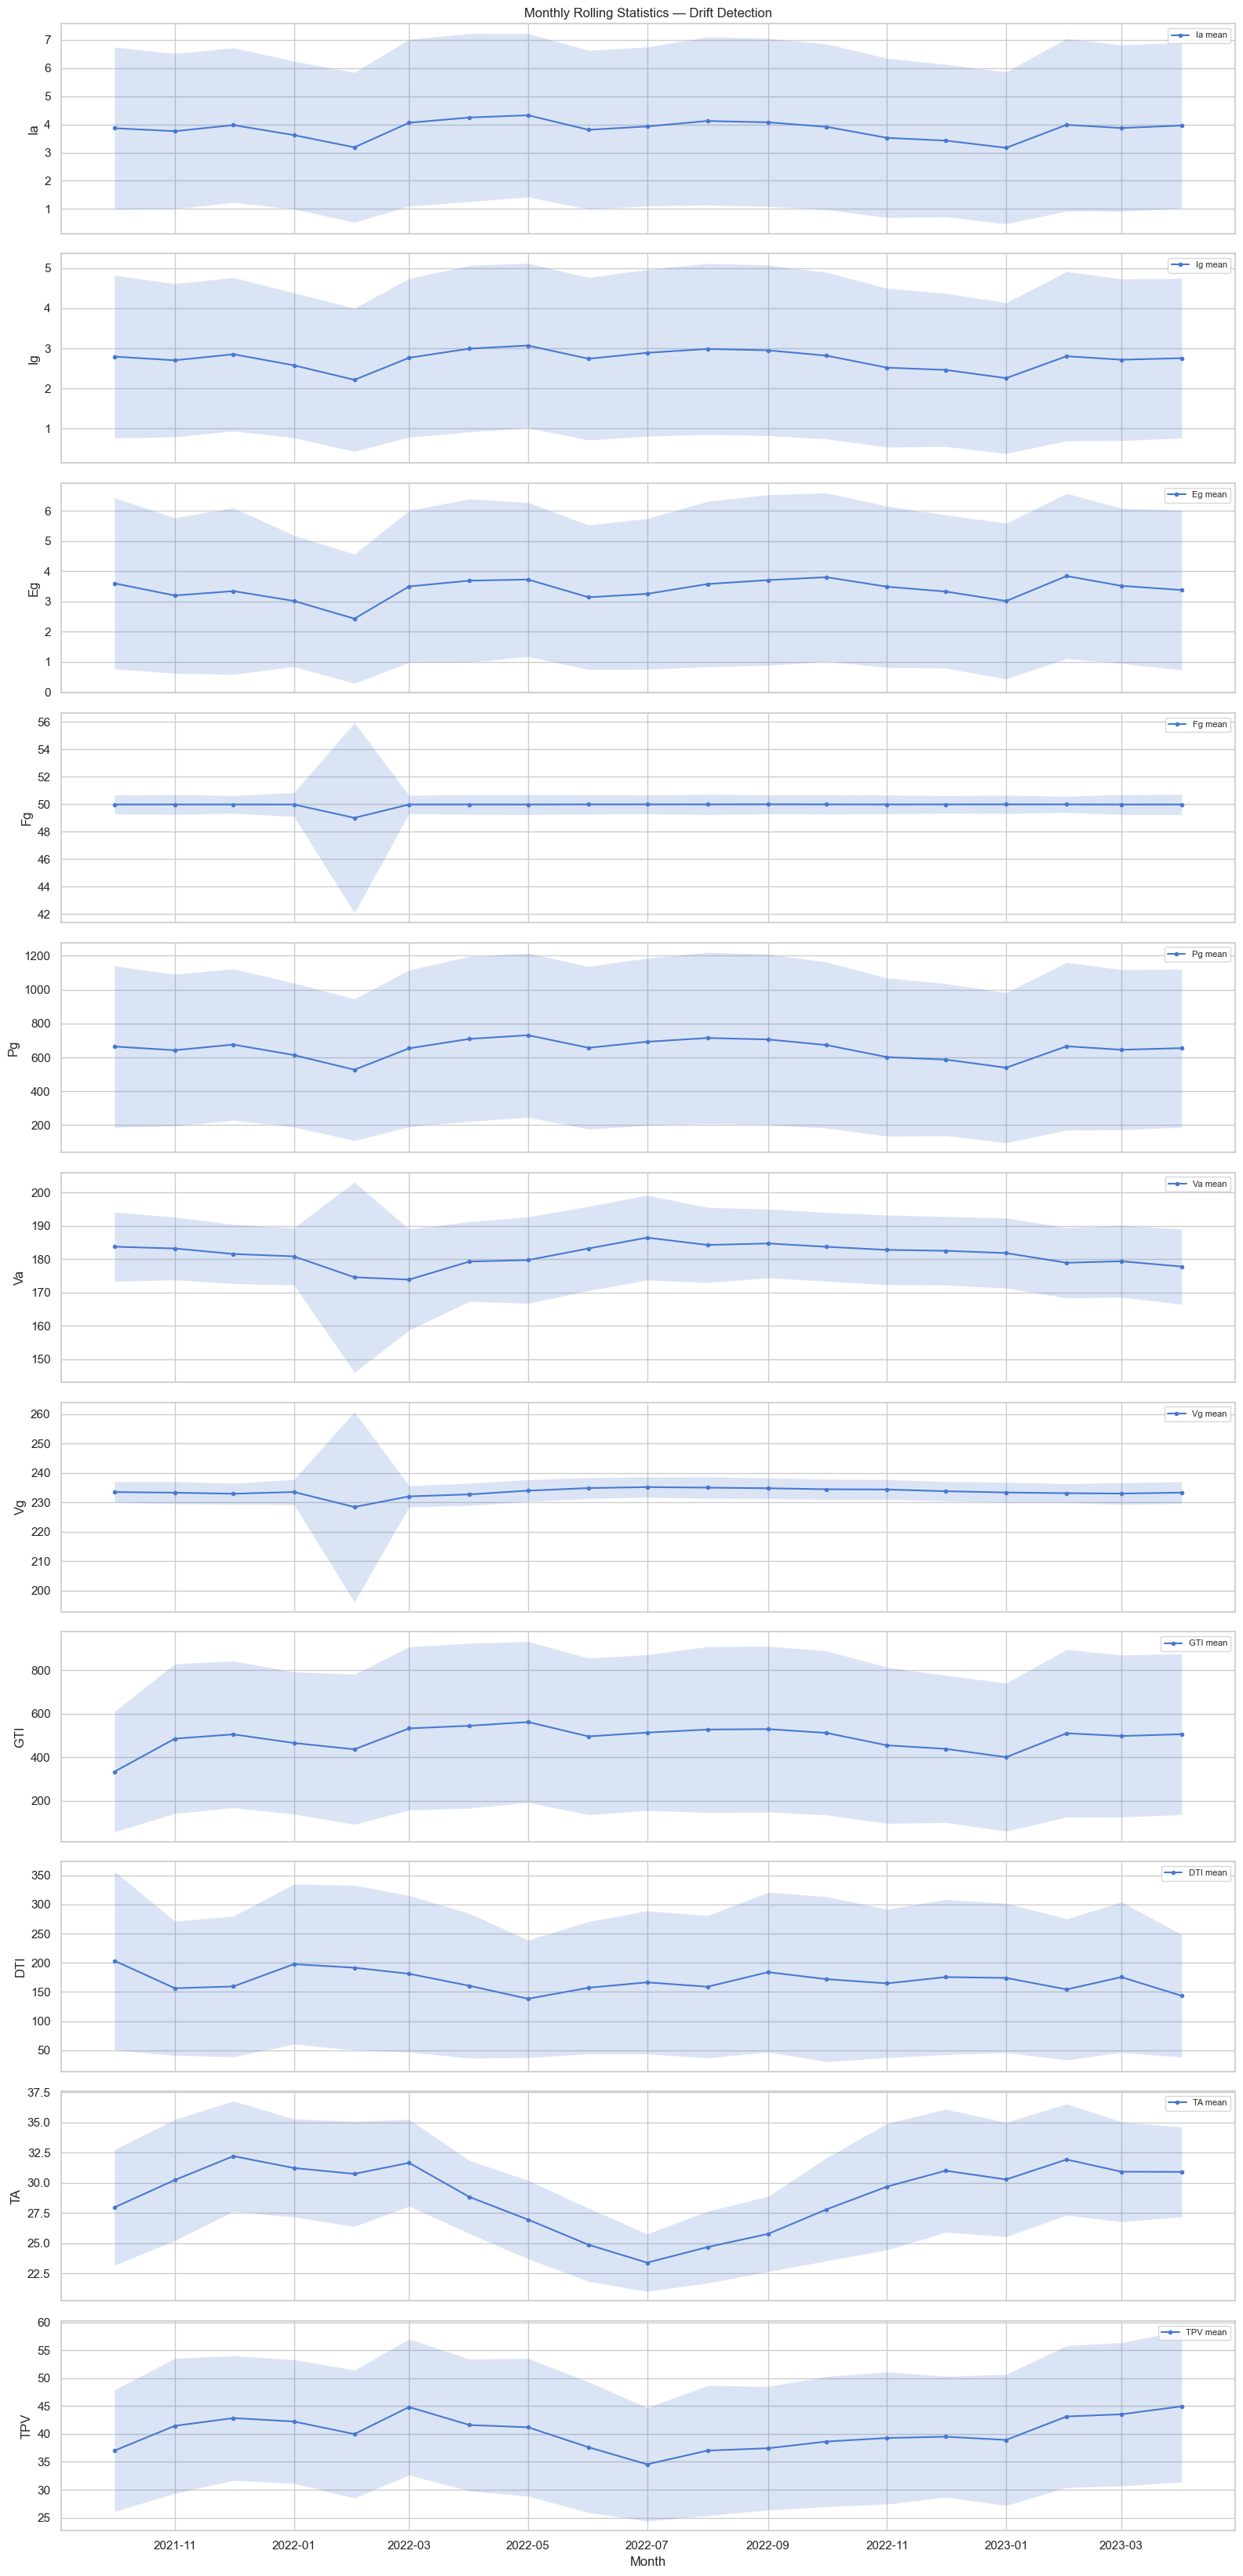

In [111]:
# Monthly rolling statistics — detect long-term drift
fig, axes = plt.subplots(len(FEATURE_COLS), 1, figsize=(16, 3 * len(FEATURE_COLS)), sharex=True)
pdf["month"] = pdf[TIME_COL].dt.tz_localize(None).dt.to_period("M")

for i, col in enumerate(FEATURE_COLS):
    monthly = pdf.groupby("month")[col].agg(["mean", "std"]).dropna()
    monthly.index = monthly.index.to_timestamp()
    axes[i].plot(monthly.index, monthly["mean"], "o-", markersize=3, label=f"{col} mean")
    axes[i].fill_between(monthly.index,
                         monthly["mean"] - monthly["std"],
                         monthly["mean"] + monthly["std"],
                         alpha=0.2)
    axes[i].set_ylabel(col)
    axes[i].legend(loc="upper right", fontsize=8)

axes[0].set_title("Monthly Rolling Statistics — Drift Detection")
axes[-1].set_xlabel("Month")
plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_monthly_drift.png", bbox_inches="tight")
plt.show()

## 12. Cumulative Energy (Eg) — Special Analysis

`Eg` is **cumulative grid energy** (kWh). It monotonically increases. This is NOT a feature for ML — it's a running sum that trivially correlates with time.

**Action:** Do NOT use Eg as a raw feature. Instead:
- Use `dEg = Eg.diff()` (instantaneous energy ≈ power) if needed, but Pg already exists
- Or drop Eg entirely (it duplicates Pg information)

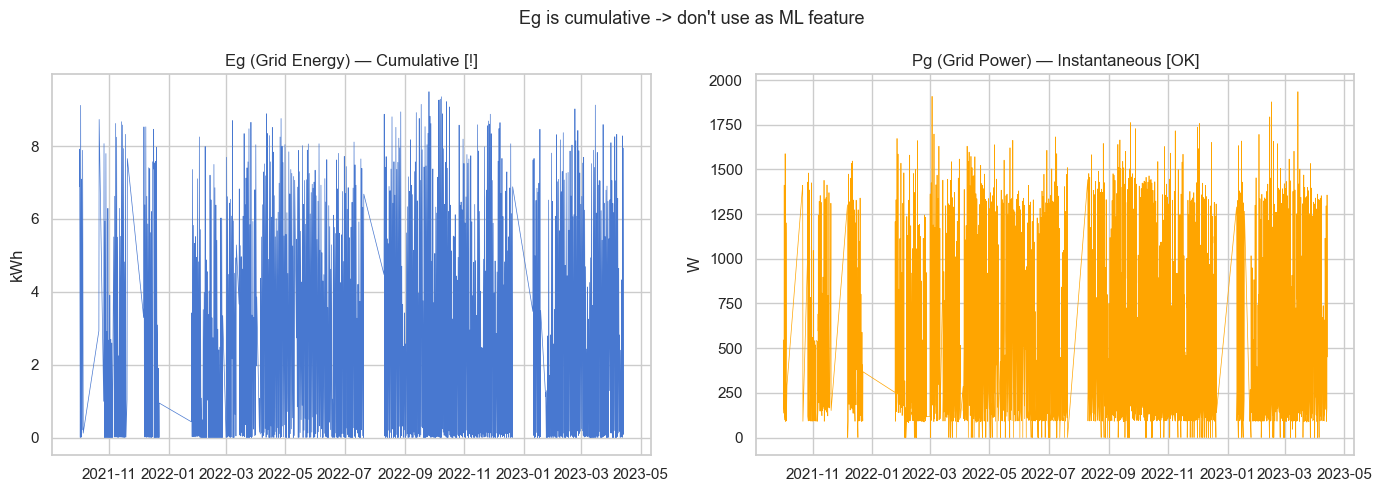

Correlation(Eg, row_index) = 0.0503
-> 


In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eg is cumulative
axes[0].plot(pdf[TIME_COL].iloc[::1000], pdf["Eg"].iloc[::1000], linewidth=0.5)
axes[0].set_title("Eg (Grid Energy) — Cumulative [!]")
axes[0].set_ylabel("kWh")

# Pg is instantaneous
axes[1].plot(pdf[TIME_COL].iloc[::1000], pdf["Pg"].iloc[::1000], linewidth=0.5, color="orange")
axes[1].set_title("Pg (Grid Power) — Instantaneous [OK]")
axes[1].set_ylabel("W")

plt.suptitle("Eg is cumulative -> don't use as ML feature", fontsize=13)
plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_eg_cumulative_warning.png", bbox_inches="tight")
plt.show()

# Compute correlation of Eg with time index (should be ~1.0)
eg_time_corr = pdf["Eg"].corr(pd.Series(range(len(pdf))))
print(f"Correlation(Eg, row_index) = {eg_time_corr:.4f}")
print(f"-> {'DANGER: Eg is a proxy for time -- will leak temporal position into model!' if abs(eg_time_corr) > 0.9 else ''}")

## 13. Differential Signal Preview (dt2 vs dt3)

**dt3** = healthy inverter 2 (same plant, same irradiance). Using the differential power signal ΔP = P_inv1 − α·P_inv2 removes common-mode disturbances (clouds, temperature shifts) and isolates fault-induced deviations.

**Expected:** large ΔP during fault periods, ΔP ≈ 0 during normal operation.

If dt3 parquet doesn't exist yet, run:  
`python -m src.data.ingestion` to generate it.

Loading dt3 (healthy inverter)...
Aligned rows: 2,988,814
α (scaling factor) = 0.9694


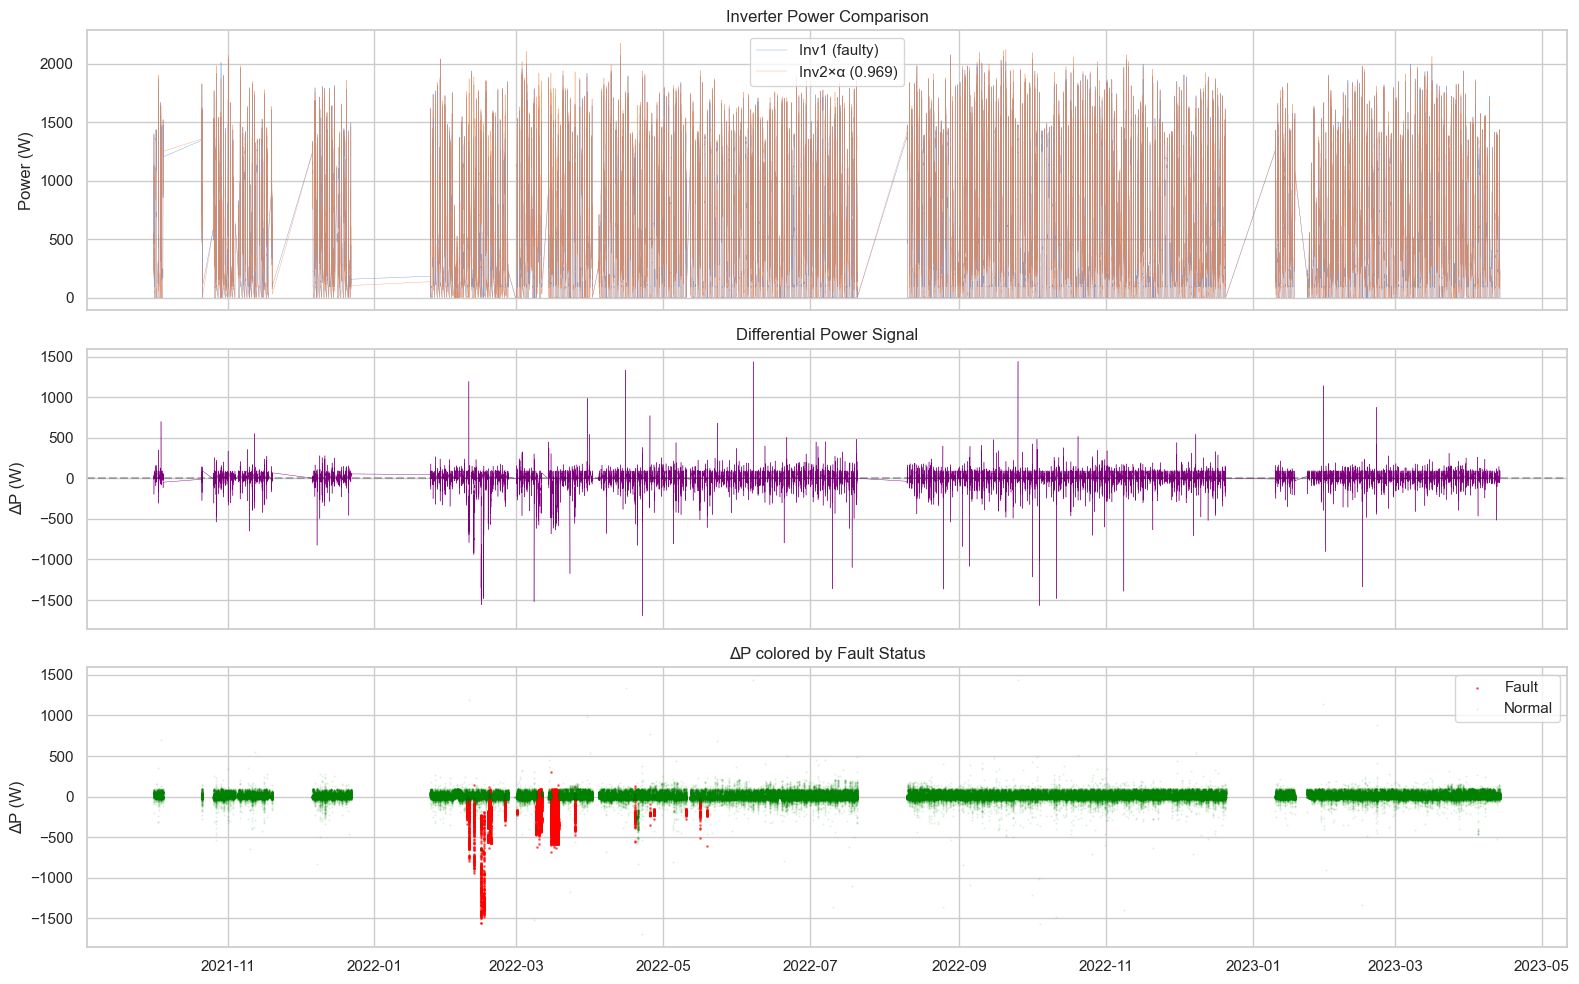


ΔP discriminative power:
  Normal mean ΔP: 8.33 W (std: 40.51)
  Fault  mean ΔP: -265.21 W (std: 281.02)
  Mann-Whitney U p-value: 0.00e+00
  Cohen's d: 1.362 (large)


In [113]:
dt3_parquet = INTERIM_DIR / "reunion_dt3_merged.parquet"
if dt3_parquet.exists():
    print("Loading dt3 (healthy inverter)...")
    df3 = pl.read_parquet(dt3_parquet).to_pandas()

    # Align dt2 and dt3 on time
    merged_diff = pdf.merge(
        df3[["time", "Pg", "Ig", "Vg"]].rename(columns={"Pg": "Pg_inv2", "Ig": "Ig_inv2", "Vg": "Vg_inv2"}),
        on="time",
        how="inner",
    )
    print(f"Aligned rows: {len(merged_diff):,}")

    # Estimate α on NORMAL daytime data only (anti-leakage!)
    normal_day = merged_diff[(merged_diff[LABEL_COL] == 0.0) & (merged_diff["is_daytime"])]
    valid = normal_day[(normal_day["Pg"] > 50) & (normal_day["Pg_inv2"] > 50)]
    alpha = (valid["Pg"] / valid["Pg_inv2"]).median()
    print(f"α (scaling factor) = {alpha:.4f}")

    # Differential power signal
    merged_diff["delta_P"] = merged_diff["Pg"] - alpha * merged_diff["Pg_inv2"]

    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    sample = merged_diff.iloc[::10]  # subsample for plotting
    axes[0].plot(sample[TIME_COL], sample["Pg"], linewidth=0.3, alpha=0.7, label="Inv1 (faulty)")
    axes[0].plot(sample[TIME_COL], sample["Pg_inv2"] * alpha, linewidth=0.3, alpha=0.7, label=f"Inv2×α ({alpha:.3f})")
    axes[0].set_ylabel("Power (W)")
    axes[0].legend()
    axes[0].set_title("Inverter Power Comparison")

    axes[1].plot(sample[TIME_COL], sample["delta_P"], linewidth=0.3, color="purple")
    axes[1].axhline(0, color="k", ls="--", alpha=0.3)
    axes[1].set_ylabel("ΔP (W)")
    axes[1].set_title("Differential Power Signal")

    fault_mask = sample[LABEL_COL] != 0.0
    axes[2].scatter(sample[TIME_COL][fault_mask], sample["delta_P"][fault_mask],
                    s=1, c="red", alpha=0.5, label="Fault")
    axes[2].scatter(sample[TIME_COL][~fault_mask], sample["delta_P"][~fault_mask],
                    s=0.3, c="green", alpha=0.1, label="Normal")
    axes[2].set_ylabel("ΔP (W)")
    axes[2].set_title("ΔP colored by Fault Status")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(INTERIM_DIR / "eda_differential_signal.png", bbox_inches="tight")
    plt.show()

    # Discriminative power of ΔP
    dp_normal = merged_diff.loc[(merged_diff[LABEL_COL] == 0.0) & (merged_diff["is_daytime"]), "delta_P"].dropna()
    dp_fault = merged_diff.loc[(merged_diff[LABEL_COL] != 0.0) & (merged_diff["is_daytime"]), "delta_P"].dropna()
    if len(dp_fault) > 10:
        stat, pval = stats.mannwhitneyu(dp_normal, dp_fault.values, alternative="two-sided")
        cohens_d_val = (dp_normal.mean() - dp_fault.mean()) / np.sqrt((dp_normal.std()**2 + dp_fault.std()**2) / 2)
        print(f"\nΔP discriminative power:")
        print(f"  Normal mean ΔP: {dp_normal.mean():.2f} W (std: {dp_normal.std():.2f})")
        print(f"  Fault  mean ΔP: {dp_fault.mean():.2f} W (std: {dp_fault.std():.2f})")
        print(f"  Mann-Whitney U p-value: {pval:.2e}")
        print(f"  Cohen's d: {abs(cohens_d_val):.3f} ({'large' if abs(cohens_d_val) > 0.8 else 'medium' if abs(cohens_d_val) > 0.5 else 'small'})")
else:
    print(f"⚠ dt3 parquet not found at {dt3_parquet}")
    print("  Run: python -m src.data.ingestion   (from PFE_Experiments/)")

### Understanding the Differential Signal (Delta P)

**The big idea:** We have TWO inverters in the same solar plant:
- **Inverter 1 (dt2):** experiences faults (our labeled data)
- **Inverter 2 (dt3):** always healthy (reference)

Both receive the SAME sunlight, temperature, and weather. So when a cloud passes, BOTH inverters' power drops equally. When temperature rises, BOTH are affected equally.

**Differential signal:** $\Delta P = P_{inv1} - \alpha \cdot P_{inv2}$

This **cancels out** common-mode effects (weather) and **isolates** fault-specific deviations:
- During **normal operation:** $\Delta P \approx 0$ (both inverters produce similar power)
- During a **fault:** $\Delta P$ deviates significantly (inv1 is impaired, inv2 is not)

**What is $\alpha$?** A scaling factor because the two inverters might have slightly different capacities. We estimate it using the MEDIAN ratio of their powers during NORMAL daytime operation:
```python
alpha = (valid["Pg"] / valid["Pg_inv2"]).median()
```
Using median (not mean) because it's robust to outliers. We only use Normal + Daytime data to avoid **leakage** (if we used fault data to estimate $\alpha$, the model indirectly "sees" fault labels).

**Cohen's d** — a measure of effect size:
$$d = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{(s_1^2 + s_2^2)/2}}$$
- Tells you *how different* two groups are in standard deviation units
- $d < 0.2$: small effect, $0.5$: medium, $> 0.8$: large
- Unlike p-values (which depend on sample size), Cohen's d measures **practical significance**

## 14. Autocorrelation Analysis

Autocorrelation affects:
- Window overlap design (overlapping windows with high autocorrelation = near-duplicate samples)
- Train/val gap sizing (leakage check #2: need enough gap to decorrelate)
- Forecasting horizon feasibility (Task C)

ACF computed on largest contiguous daytime segment: 8,180 rows


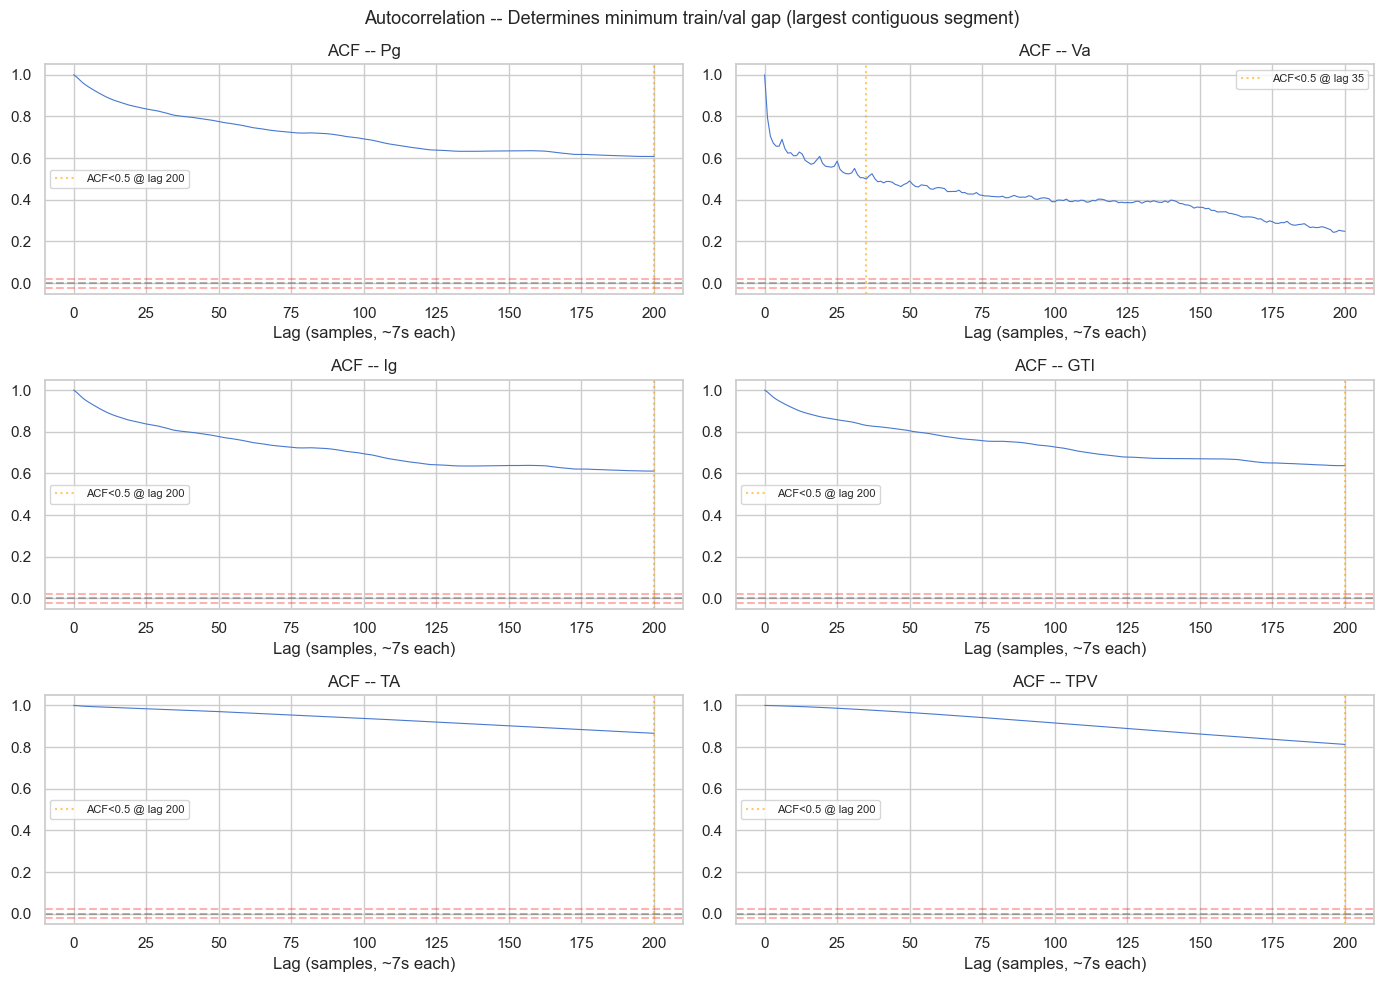

In [114]:
from statsmodels.tsa.stattools import acf

# Use the LARGEST contiguous segment for ACF (must be truly sequential)
pdf_day_largest = pdf_day[pdf_day["segment_id"] == largest_seg_id]
print(f"ACF computed on largest contiguous daytime segment: {len(pdf_day_largest):,} rows")

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
acf_features = ["Pg", "Va", "Ig", "GTI", "TA", "TPV"]
acf_features = [f for f in acf_features if f in pdf_day_largest.columns and pdf_day_largest[f].notna().sum() > 1000]

for i, col in enumerate(acf_features[:6]):
    ax = axes.ravel()[i]
    series = pdf_day_largest[col].dropna().values[:50_000]  # first 50K from contiguous segment
    nlags = min(200, len(series) // 2 - 1)
    acf_vals = acf(series, nlags=nlags, fft=True)
    ax.plot(range(nlags + 1), acf_vals, linewidth=0.8)
    ax.axhline(0, color="k", ls="--", alpha=0.3)
    ax.axhline(1.96 / np.sqrt(len(series)), color="red", ls="--", alpha=0.3)
    ax.axhline(-1.96 / np.sqrt(len(series)), color="red", ls="--", alpha=0.3)
    ax.set_title(f"ACF -- {col}")
    ax.set_xlabel("Lag (samples, ~7s each)")
    # Find lag where ACF drops below 0.5
    decay_lag = np.argmax(acf_vals < 0.5) if np.any(acf_vals < 0.5) else nlags
    ax.axvline(decay_lag, color="orange", ls=":", alpha=0.6, label=f"ACF<0.5 @ lag {decay_lag}")
    ax.legend(fontsize=8)

plt.suptitle("Autocorrelation -- Determines minimum train/val gap (largest contiguous segment)", fontsize=13)
plt.tight_layout()
plt.savefig(INTERIM_DIR / "eda_autocorrelation.png", bbox_inches="tight")
plt.show()

### Understanding Autocorrelation (ACF)

**Autocorrelation** measures how similar a signal is to a DELAYED version of itself:

$$ACF(k) = \frac{\sum_{t=1}^{n-k}(x_t - \bar{x})(x_{t+k} - \bar{x})}{\sum_{t=1}^{n}(x_t - \bar{x})^2}$$

- $ACF(0) = 1$ always (a signal is perfectly correlated with itself)
- $ACF(1)$: correlation between each value and the NEXT value
- $ACF(k)$: correlation at lag $k$ (value now vs value $k$ steps later)

**Intuition:** If the power at 10:00:00 is 500W, what's the power at 10:00:07 (lag 1)? Probably ~500W too — solar power doesn't jump randomly. That's high autocorrelation.

**Why this matters for our pipeline:**

1. **Window overlap:** We'll create 60-sample windows with 30-sample overlap. If ACF is still high at lag 30, our overlapping windows are nearly identical → the model sees near-duplicate samples → overly optimistic accuracy.

2. **Train/val gap:** In time-series ML, you need a GAP between train and validation sets. The gap should be large enough that train samples are NOT correlated with val samples. The ACF tells us how large this gap must be.

3. **Forecasting horizon (Task C):** If ACF drops to 0.5 at lag 20, the signal becomes unpredictable ~140s out. This limits how far ahead we can reliably forecast.

**The orange line** (`ACF<0.5 @ lag N`): This is where autocorrelation drops below 0.5 — the "decorrelation lag." At ~7s per sample, lag 20 ≈ 140 seconds.

**Red dashed lines** ($\pm 1.96/\sqrt{n}$): The 95% confidence interval for "no autocorrelation." ACF values within these lines are statistically indistinguishable from zero.

## 15. Key Findings & EDA Summary

After running all cells above, document key findings here for the next pipeline step (feature engineering & splitting).

In [115]:
print("=" * 60)
print("EDA SUMMARY -- La Reunion PV Fault Detection")
print("=" * 60)

print(f"""
DATASET:
  Rows:       {len(pdf):,}
  Time range: {t_min} -> {t_max} ({(t_max - t_min).days} days)
  Sampling:   ~7s (median: {dt_seconds.median():.1f}s)
  Features:   {len(FEATURE_COLS)} ({len(ELECTRICAL_COLS)} electrical + {len(METEO_COLS)} meteorological)
  Timezone:   UTC (La Reunion = UTC+4)

GAPS & SEGMENTATION:
  Gaps > 1 min:      {n_gaps}
  Max gap:           {gap_durations.max()/3600:.1f}h ({gap_durations.max()/86400:.1f} days)
  Segments (>{GAP_THRESHOLD_S}s threshold): {len(seg_stats)}
  Usable segments (>={MIN_WINDOW_SIZE} rows): {len(usable)} ({usable_rows:,} rows, {usable_rows/len(pdf)*100:.1f}%)

CLASS IMBALANCE:
  Normal:     {binary_normal:,} ({binary_normal/len(pdf)*100:.2f}%)
  Fault:      {binary_fault:,} ({binary_fault/len(pdf)*100:.2f}%)
  Ratio:      1:{binary_normal/binary_fault:.0f}

MISSING DATA:
{null_report[null_report['null_count'] > 0][['null_count', 'null_pct']].to_string()}

ACTIONABLE FINDINGS:
  1. Eg is CUMULATIVE -> MUST exclude from features (use Pg instead)
  2. Night data is trivially normal -> compute metrics on DAYTIME ONLY
  3. Meteorological nulls concentrated in first ~27 days -> trim or handle
  4. Timestamps are UTC, local time = UTC+4 (affects hour-of-day features)
  5. 513 gaps detected -> segment-aware windowing is MANDATORY
  6. segment_id column added to enforce no cross-gap windows
  7. Autocorrelation decay determines minimum train/val gap
  8. Differential signal (delta_P from dt3) is a powerful discriminative feature
  9. Check collinearity results above for redundant feature pairs

NEXT STEPS:
  -> Feature engineering (physics features, window statistics) -- per segment
  -> Time-based train/val/test split (at segment boundaries, with ACF gap)
  -> Run leakage checks on the split
  -> Baseline models
""")

EDA SUMMARY -- La Reunion PV Fault Detection

DATASET:
  Rows:       2,988,814
  Time range: 2021-10-01 10:10:02+00:00 -> 2023-04-13 13:42:27+00:00 (559 days)
  Sampling:   ~7s (median: 6.0s)
  Features:   11 (7 electrical + 4 meteorological)
  Timezone:   UTC (La Reunion = UTC+4)

GAPS & SEGMENTATION:
  Gaps > 1 min:      513
  Max gap:           791.3h (33.0 days)
  Segments (>300s threshold): 465
  Usable segments (>=60 rows): 455 (2,988,507 rows, 100.0%)

CLASS IMBALANCE:
  Normal:     2,904,289 (97.17%)
  Fault:      84,525 (2.83%)
  Ratio:      1:34

MISSING DATA:
       null_count  null_pct
TPV         50992      1.71
DTI         50992      1.71
GTI         50992      1.71
TA          50992      1.71
Fault           6      0.00
Ia             10      0.00
Pg             10      0.00
Fg             10      0.00
Eg             10      0.00
Ig             10      0.00
Va             10      0.00
Vg             10      0.00

ACTIONABLE FINDINGS:
  1. Eg is CUMULATIVE -> MUST exclude

---
## Appendix: When to Run Each Type of Test

| Test | When | Why |
|------|------|-----|
| **Collinearity (VIF)** | Before + after feature engineering | Avoid redundant features |
| **Mutual Information** | Before + after feature engineering | Rank feature informativeness |
| **Temporal integrity** | Immediately after splitting | Verify no future → past leak |
| **Preprocessor fit scope** | During pipeline construction | Verify fit(train) only |
| **Label shuffle test** | After first model training | Detect target leakage |
| **Duplicate check** | After windowing + splitting | Detect window overlap leak |
| **Feature importance audit** | After tree model training | Detect proxy features |
| **Performance sanity** | After every experiment | Flag impossibly good results |
| **Bootstrap CI** | When comparing two models | Quantify uncertainty |
| **Wilcoxon + Cohen's d** | When claiming model A > B | Statistical significance |
| **ADF stationarity** | During EDA | Inform preprocessing choices |
| **Mann-Whitney U** | During EDA | Feature discriminative power |